# Overview (Candidate)
* Separate male/female from the dataset
* Add medication to the male/female dataset
* Impute NaNs

In [1]:
# path to user functions
import sys  
sys.path.append('../Src/')

import pandas as pd
import pickle
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import sys

from scipy import stats
from importlib.metadata import version

# set seaborn theme
sns.set_theme()

# python modules
import utilities as u
import plot
import custom_impute as ci

# initializing variables
SEED = 1776

# Create a dictionary of versions
versions = {
    "Python": sys.version.split()[0],
    "Pandas": pd.__version__,
    "NumPy": np.__version__,
    "Seaborn": sns.__version__,
    "Matplot": sys.modules['matplotlib'].__version__,
    # "Sk-Learn": sys.modules['sklearn'].__version__,
    "Scipy": sys.modules['scipy'].__version__,
}

# Display as a clean DataFrame
df_versions = pd.DataFrame(list(versions.items()), columns=['Library', 'Version'])
print(df_versions)

# adjust pandas display options to max
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# adjust pandas display options to ensure full display of content
pd.set_option('display.max_colwidth', None)

   Library  Version
0   Python  3.11.13
1   Pandas    2.3.1
2    NumPy    2.3.2
3  Seaborn   0.13.2
4  Matplot   3.10.5
5    Scipy   1.16.1


## Import Data

In [2]:
# import data
df = pd.read_pickle("../Data/CAN_Heart_Data.pkl")
# display
df.head()

,PreviousTransplantNumber_CAN,WaitListDiagnosisCode_CAN,Gender_CAN,BloodGroup_CAN,Citizenship_CAN,ResidencyStateRegistration_CAN,EducationLevel_CAN,LifeSupportRegistration_ECMO_CAN,LifeSupportRegistration_IABP_CAN,LifeSupportInhaled_CAN,InotropesIVRegistration_CAN,LifeSupportRegistration_PGE_CAN,LifeSupportMechanismRegistration_OTHER_CAN,VentricularDeviceTypeRegistration_CAN,VentricularDeviceBrandRegistration_CAN,FunctionalStatusRegistration_CAN,PrimaryPaymentRegistration_CAN,DiagnosisAtListing_CAN,DiabetesType_CAN,DialysisTypeRegistration_CAN,CerebroVascularDisease_CAN,PreviousMalignancy_CAN,CreatinineRegistration_CAN,DefibrillatorImplantRegistration_CAN,HemodynamicsRegistration_SYS_CAN,HemodynamicsRegistration_PA_DIA_CAN,HemodynamicsRegistration_PA_MN_CAN,HemodynamicsRegistration_PCW_CAN,HemodynamicsRegistration_CO_CAN,InotropesVasodilatorsRegistration_SYS_CAN,InotropesVasodilatorsRegistration_DIA_CAN,InotropesVasodilatorsRegistration_MN_CAN,InotropesVasodilatorsRegistration_PCW_CAN,InotropesVasodilatorsRegistration_CO_CAN,CigaretteUse_CAN,CigaretteAbstinence_CAN,PriorCardiacSurgery_CAN,PriorCardiacSurgeryType_CAN,ReceivedDeceasedDonorTramsplant_CAN,TotalDayWaitList_CAN,StatusAtTransplant_CAN,Age_Listing_CAN,LifeSupportRegistration_CAN,Ethnicity_CAN,HeightCm_CAN,WeightKg_CAN,VentilatorRegistration_CAN,TransplantRegion_CAN,WorkIncomeRegistration_CAN,AntigenBW4_CAN,AntigenBW6_CAN,AntigenC1_CAN,AntigenC2_CAN,AntigenDR51_CAN,AntigenDR51_2_CAN,AntigenDR52_CAN,AntigenDR52_2_CAN,AntigenDR53_CAN,AntigenDR53_2_CAN,AntigenDQ1_CAN,AntigenDQ2_CAN,FunctionalStatusTransplant_CAN,MedicalConditionTransplant_CAN,PrimaryPaymentTransplant_CAN,LifeSupportTransplant_ECMO_CAN,ResidencyStateTransplant_CAN,WorkIncomeTransplant_CAN,LifeSupportTransplant_PGE_CAN,CreatinineTransplant_CAN,DialysisBetweenRegistrationTransplant_CAN,HemodynamicsTransplant_CO_CAN,HemodynamicsTransplant_PA_DIA_CAN,HemodynamicsTransplant_PA_MN_CAN,HemodynamicsTransplant_PCW_CAN,HemodynamicsTransplant_SYS_CAN,LifeSupportTransplant_IABP_CAN,InfectionTherapyIV_CAN,InotropesIVTransplant_CAN,InotropesVasodilatorsTransplant_CO_CAN,InotropesVasodilatorsTransplant_DIA_CAN,InotropesVasodilatorsTransplant_MN_CAN,InotropesVasodilatorsTransplant_PCW_CAN,InotropesVasodilatorsTransplant_SYS_CAN,LifeSupportMechanismTransplant_OTHER_CAN,PriorLungSurgeryAfterRegistration_CAN,SteroidsUse_CAN,TotalBilirubinTransplant_CAN,TransfusionAfterRegistration_CAN,VentricularDeviceTypeTransplant_CAN,VentricularDeviceBrandTransplant_CAN,VentilatorySupport_CAN,VentilatorTransplant_CAN,LifeSupportInhaledTransplant_CAN,PriorCardiacSurgeryTypeListAndTransplant_CAN,Hepatitis_B_CoreAntibody_CAN,SurfaceAntigenHEP_B_CAN,SurfaceHBVAntibodyTotalTransplant_CAN,CMVStatus_Transplant_CAN,HIV_SeroStatusTransplant_CAN,HEP_C_SerostatusStatus_CAN,EpsteinBarrSeroStatusTransplant_CAN,HIV_NAT_PreTransplant_CAN,HCV_NAT_PreTranspant_CAN,HBV_NAT_Result_CAN,LifeSupportInhaledRegistration_CAN,PreviousTransplantSameOrgan_CAN,PreviousTransplantAnyOrgan_CAN,AntigenRA1_CAN,AntigenRA2_CAN,AntigenRB1_CAN,AntigenRB2_CAN,AntigenRDR1_CAN,AntigenRDR2_CAN,MalignancyBetweenRegistrationTransplant_CAN,CMV_IGG_Transplant_CAN,CMV_IGM_Transplant_CAN,TransplantType_CAN,Age_CAN,PrimaryDiagnosisType_CAN,DialysisPriorRegistration_CAN,LifeSupportTransplant_CAN,PriorCardiacSurgeryListAndTransplant_CAN,Malignancy_CAN,DistanceFromHospitaltoTXCenter_CAN,VentilatorySupportAfterRegistration_CAN,HeartProcedureType_CAN,TransplantYear_CAN,ListingYear_CAN,TransplantSurvivalDay
0,0,DILATED MYOPATHY: IDIOPATHIC,M,A,US Citizen,CA,ATTENDED COLLEGE/TECHNICAL SCHOOL,No,No,No,No,No,Yes,Lvad+Rvad,CentriMag (Thoratec/Levitronix),0.1,Public insurance - Medicaid,DILATED MYOPATHY: IDIOPATHIC,No,No dialysis,No,No,1.3,Yes,50.0,34.0,37.0,36.0,2.50,Yes,Yes,Yes,Yes,Yes,No,Missing,Yes,Valve Replace/Repair,Yes,11,Hypoplastic Left Heart Syndrome; Atrioventricular Septal Defect; Other left Heart Valvar/Structural,45,Yes,Hispanic,172.7,65.8,No,Region 5,No,0,0,0,0,0,0,0,0,0,0,0,0,0.1,

In [3]:
df.info(max_cols=df.shape[1])

<class 'pandas.core.frame.DataFrame'>
Index: 28326 entries, 0 to 28750
Data columns (total 129 columns):
 #    Column                                        Non-Null Count  Dtype   
---   ------                                        --------------  -----   
 0    PreviousTransplantNumber_CAN                  28326 non-null  category
 1    WaitListDiagnosisCode_CAN                     28326 non-null  category
 2    Gender_CAN                                    28326 non-null  category
 3    BloodGroup_CAN                                28326 non-null  category
 4    Citizenship_CAN                               28326 non-null  category
 5    ResidencyStateRegistration_CAN                28326 non-null  category
 6    EducationLevel_CAN                            28326 non-null  category
 7    LifeSupportRegistration_ECMO_CAN              28326 non-null  category
 8    LifeSupportRegistration_IABP_CAN              28326 non-null  category
 9    LifeSupportInhaled_CAN                    

## Gender

In [4]:
u.any_nans(df)

--- Missing Values Found () (Total Rows: 28,326) ---
                                     Count Percentage
HemodynamicsRegistration_PCW_CAN      2642    9.3271%
HemodynamicsTransplant_PCW_CAN        2050    7.2372%
HemodynamicsRegistration_CO_CAN       1588    5.6062%
FunctionalStatusTransplant_CAN        1352    4.7730%
HemodynamicsRegistration_PA_MN_CAN    1264    4.4623%
HemodynamicsTransplant_CO_CAN         1240    4.3776%
HemodynamicsTransplant_PA_MN_CAN      1064    3.7563%
HemodynamicsRegistration_PA_DIA_CAN    997    3.5197%
HemodynamicsRegistration_SYS_CAN       976    3.4456%
FunctionalStatusRegistration_CAN       952    3.3609%
HemodynamicsTransplant_PA_DIA_CAN      802    2.8313%
HemodynamicsTransplant_SYS_CAN         782    2.7607%
TotalBilirubinTransplant_CAN            96    0.3389%
CreatinineRegistration_CAN              95    0.3354%
CreatinineTransplant_CAN                55    0.1942%
WeightKg_CAN                             7    0.0247%


In [5]:
df.Gender_CAN.value_counts(dropna=False)

Gender_CAN
M    20737
F     7589
Name: count, dtype: int64

In [6]:
df_m = df[df.Gender_CAN == 'M'].copy()
df_f = df[df.Gender_CAN == 'F'].copy()
#
df_m.shape, df_f.shape

((20737, 129), (7589, 129))

### User Function(s)

In [7]:
def plot_histogram(data, column, bins=30, txt='', title_font=20, tick_font=10, KDE=True):
    """
    Plotting histograms of multiple columns in a single figure. 
    """
    plt.figure(figsize=(10, 6))  # width, height in inches
    # plot
    ax = sns.histplot(
        data=data,
        x=column,
        kde=KDE,
        bins=bins
    )
    # aesthetics
    plt.title(f"{txt}", fontsize=title_font)
    plt.ylabel("Frequency", fontsize=tick_font, fontweight='bold')
    plt.xlabel(column, fontsize=tick_font, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Hemodynamics Registration

#### Male

In [8]:
# info
features = u.get_feature_info(df_m, 'HemodynamicsRegistration', cat=False)

                                       count       mean        std   min   25%   50%   75%    max
HemodynamicsRegistration_CO_CAN      19590.0   4.426968   1.350360  0.39   3.5   4.3   5.2   15.0
HemodynamicsRegistration_PA_DIA_CAN  20056.0  20.843448   8.781906  0.00  15.0  20.0  27.0   83.0
HemodynamicsRegistration_PA_MN_CAN   19831.0  29.059915  10.312086  0.00  21.0  29.0  36.0   87.0
HemodynamicsRegistration_PCW_CAN     18801.0  19.533855   8.894973  0.00  13.0  19.0  25.0   50.0
HemodynamicsRegistration_SYS_CAN     20073.0  42.636626  14.453643  0.00  32.0  42.0  52.0  123.0

:::: NaN Count:
HemodynamicsRegistration_CO_CAN        1147
HemodynamicsRegistration_PA_DIA_CAN     681
HemodynamicsRegistration_PA_MN_CAN      906
HemodynamicsRegistration_PCW_CAN       1936
HemodynamicsRegistration_SYS_CAN        664 



Those hemodynamic variables (Cardiac Output, Pulmonary Artery pressures, and Wedge pressure) are notorious for having missing data in donor registries because they require invasive Swan-Ganz catheterization, which isn't performed on every donor.

* CO (Cardiac Output)
* PA_DIA (Pulmonary Artery Diastolic)
* PA_MN (Pulmonary Artery Mean)
* PCW (Pulmonary Capillary Wedge)
* SYS (Systemic Arterial Systolic)

In [9]:
df_m[features].corr()

,HemodynamicsRegistration_CO_CAN,HemodynamicsRegistration_PA_DIA_CAN,HemodynamicsRegistration_PA_MN_CAN,HemodynamicsRegistration_PCW_CAN,HemodynamicsRegistration_SYS_CAN
HemodynamicsRegistration_CO_CAN,1.000000,-0.235612,-0.213548,-0.259455,-0.176352
HemodynamicsRegistration_PA_DIA_CAN,-0.235612,1.000000,0.895528,0.822832,0.783811
HemodynamicsRegistration_PA_MN_CAN,-0.213548,0.895528,1.000000,0.839889,0.920671
HemodynamicsRegistration_PCW_CAN,-0.259455,0.822832,0.839889,1.000000,0.764891
HemodynamicsRegistration_SYS_CAN,-0.176352,0.783811,0.920671,0.764891,1.000000


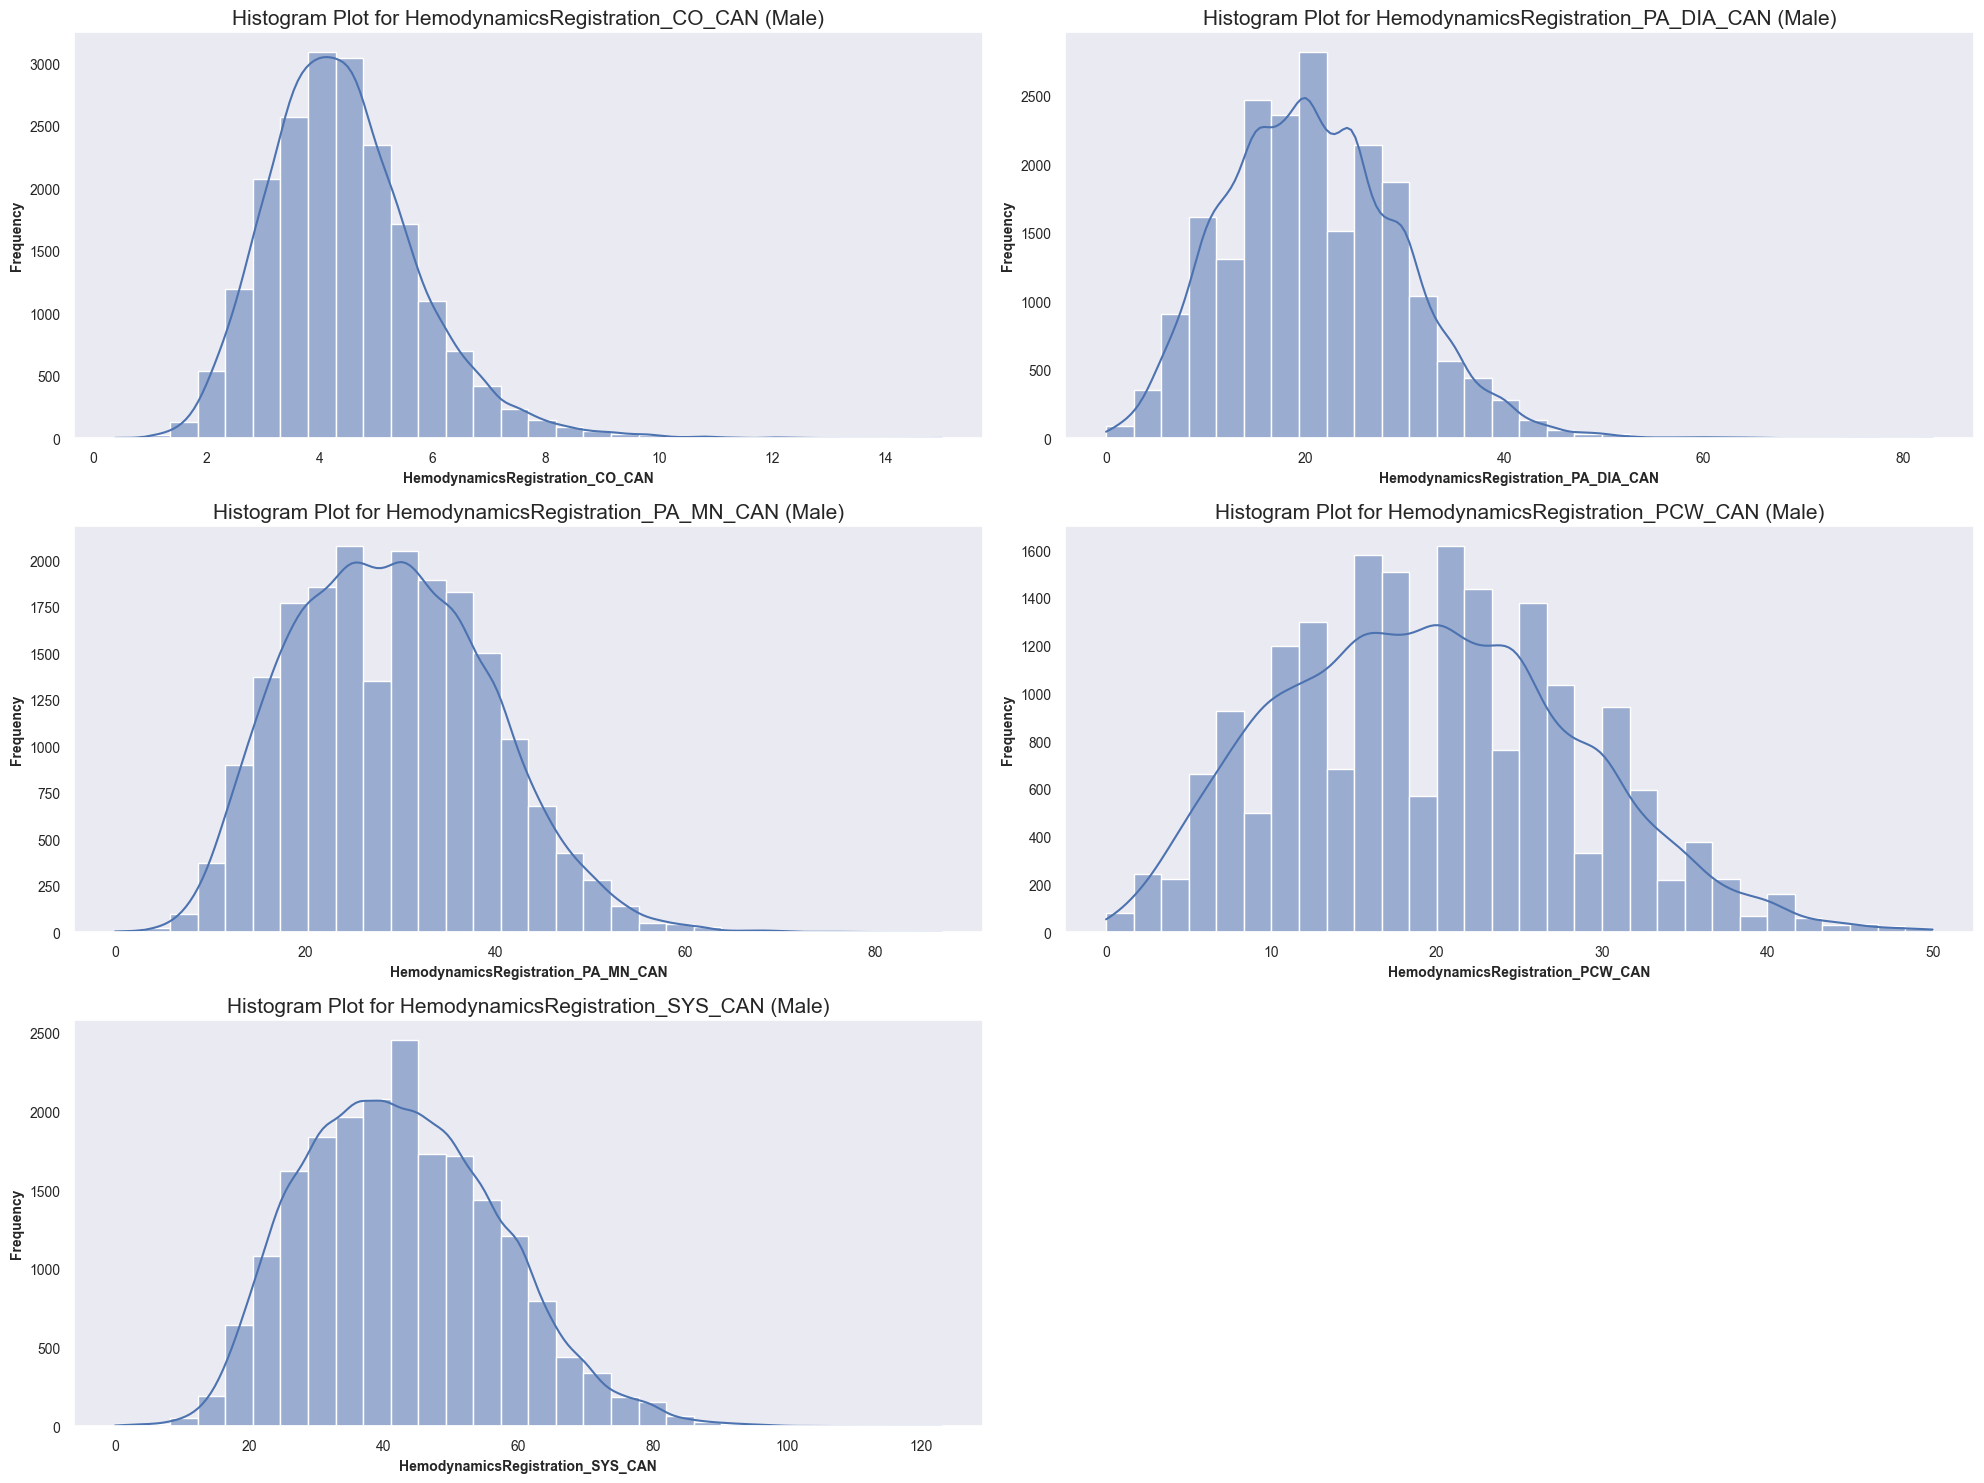

In [10]:
plot.plot_histogram(df_m, features, bins=30, txt='(Male)')

In [11]:
u.check_informative_missingness(df_m, 'HemodynamicsRegistration_CO_CAN', txt='Male')

--- Missingness (Male): HemodynamicsRegistration_CO_CAN ---
Group Sizes:    (Unknown=1,147, Known=19,590)
Mean survival:  (Unknown=1,287.9d, Known=1,331.9d)
Difference:     -44.1 days

--- Welch's t-test Analysis ---
ρ-Value: 0.1953
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     -0.0415 (Negligible)
95% CI:        [-0.1010, 0.0181]
Result: Likely Random Missingness (Effect size not significant)



In [12]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsRegistration_CO_CAN', txt='Male')

--- Value Predicts Survival (Male): HemodynamicsRegistration_CO_CAN ---
Pearson r=-0.001, p=0.8591 & Approx. Variance Explained=0.000%
Spearman r=0.001, p=0.8631 & Approx. Variance Explained=0.000%



#### Median Imputation

In [13]:
# Median impute
df_m['HemodynamicsRegistration_CO_CAN'] = df_m['HemodynamicsRegistration_CO_CAN'].fillna(
    df_m['HemodynamicsRegistration_CO_CAN'].median()
)

In [14]:
u.check_informative_missingness(df_m, 'HemodynamicsRegistration_PA_DIA_CAN', txt='Male')

--- Missingness (Male): HemodynamicsRegistration_PA_DIA_CAN ---
Group Sizes:    (Unknown=681, Known=20,056)
Mean survival:  (Unknown=1,219.0d, Known=1,333.3d)
Difference:     -114.3 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0100
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.1076 (Negligible)
95% CI:        [-0.1840, -0.0312]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



#### The "Shadow Variable" (Indicator) + Median Imputation

In [15]:
# impute: median and use new feature for NANS
df_m['HemodynamicsRegistration_PA_DIA_Ismissing'] = df_m['HemodynamicsRegistration_PA_DIA_CAN'].isna().astype(int)
df_m['HemodynamicsRegistration_PA_DIA_CAN'] = df_m['HemodynamicsRegistration_PA_DIA_CAN'].fillna(
    df_m['HemodynamicsRegistration_PA_DIA_CAN'].median()
)

In [16]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsRegistration_PA_DIA_CAN', txt='Male')

--- Value Predicts Survival (Male): HemodynamicsRegistration_PA_DIA_CAN ---
Pearson r=0.026, p=0.0001581 & Approx. Variance Explained=0.069%
Spearman r=0.024, p=0.0006538 & Approx. Variance Explained=0.056%



In [17]:
u.check_informative_missingness(df_m, 'HemodynamicsRegistration_PA_MN_CAN', txt='Male')

--- Missingness (Male): HemodynamicsRegistration_PA_MN_CAN ---
Group Sizes:    (Unknown=906, Known=19,831)
Mean survival:  (Unknown=1,357.7d, Known=1,328.2d)
Difference:     29.5 days

--- Welch's t-test Analysis ---
ρ-Value: 0.4556
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     0.0278 (Negligible)
95% CI:        [-0.0388, 0.0944]
Result: Likely Random Missingness (Effect size not significant)



In [18]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsRegistration_PA_MN_CAN', txt='Male')

--- Value Predicts Survival (Male): HemodynamicsRegistration_PA_MN_CAN ---
Pearson r=0.035, p=6.787e-07 & Approx. Variance Explained=0.124%
Spearman r=0.032, p=5.721e-06 & Approx. Variance Explained=0.104%



#### Median Imputation

In [19]:
# Median impute
df_m['HemodynamicsRegistration_PA_MN_CAN'] = df_m['HemodynamicsRegistration_PA_MN_CAN'].fillna(
    df_m['HemodynamicsRegistration_PA_MN_CAN'].median()
)

In [20]:
u.check_informative_missingness(df_m, 'HemodynamicsRegistration_PCW_CAN', txt='Male')

--- Missingness (Male): HemodynamicsRegistration_PCW_CAN ---
Group Sizes:    (Unknown=1,936, Known=18,801)
Mean survival:  (Unknown=1,330.9d, Known=1,329.4d)
Difference:     1.6 days

--- Welch's t-test Analysis ---
ρ-Value: 0.9523
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     0.0015 (Negligible)
95% CI:        [-0.0453, 0.0482]
Result: Likely Random Missingness (Effect size not significant)



In [21]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsRegistration_PCW_CAN', txt='Male')

--- Value Predicts Survival (Male): HemodynamicsRegistration_PCW_CAN ---
Pearson r=0.036, p=5.977e-07 & Approx. Variance Explained=0.132%
Spearman r=0.033, p=6.236e-06 & Approx. Variance Explained=0.109%



#### Median Imputation

In [22]:
# Median impute
df_m['HemodynamicsRegistration_PCW_CAN'] = df_m['HemodynamicsRegistration_PCW_CAN'].fillna(
    df_m['HemodynamicsRegistration_PCW_CAN'].median()
)

In [23]:
u.check_informative_missingness(df_m, 'HemodynamicsRegistration_SYS_CAN', txt='Male')

--- Missingness (Male): HemodynamicsRegistration_SYS_CAN ---
Group Sizes:    (Unknown=664, Known=20,073)
Mean survival:  (Unknown=1,216.1d, Known=1,333.3d)
Difference:     -117.1 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0091
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.1103 (Negligible)
95% CI:        [-0.1876, -0.0330]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



In [24]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsRegistration_SYS_CAN', txt='Male')

--- Value Predicts Survival (Male): HemodynamicsRegistration_SYS_CAN ---
Pearson r=0.038, p=4.9e-08 & Approx. Variance Explained=0.148%
Spearman r=0.036, p=4.238e-07 & Approx. Variance Explained=0.127%



#### The "Shadow Variable" (Indicator) + Median Imputation

In [25]:
# impute: median and use new feature for NANS
df_m['HemodynamicsRegistration_SYS_Ismissing'] = df_m['HemodynamicsRegistration_SYS_CAN'].isna().astype(int)
df_m['HemodynamicsRegistration_SYS_CAN'] = df_m['HemodynamicsRegistration_SYS_CAN'].fillna(
    df_m['HemodynamicsRegistration_SYS_CAN'].median()
)

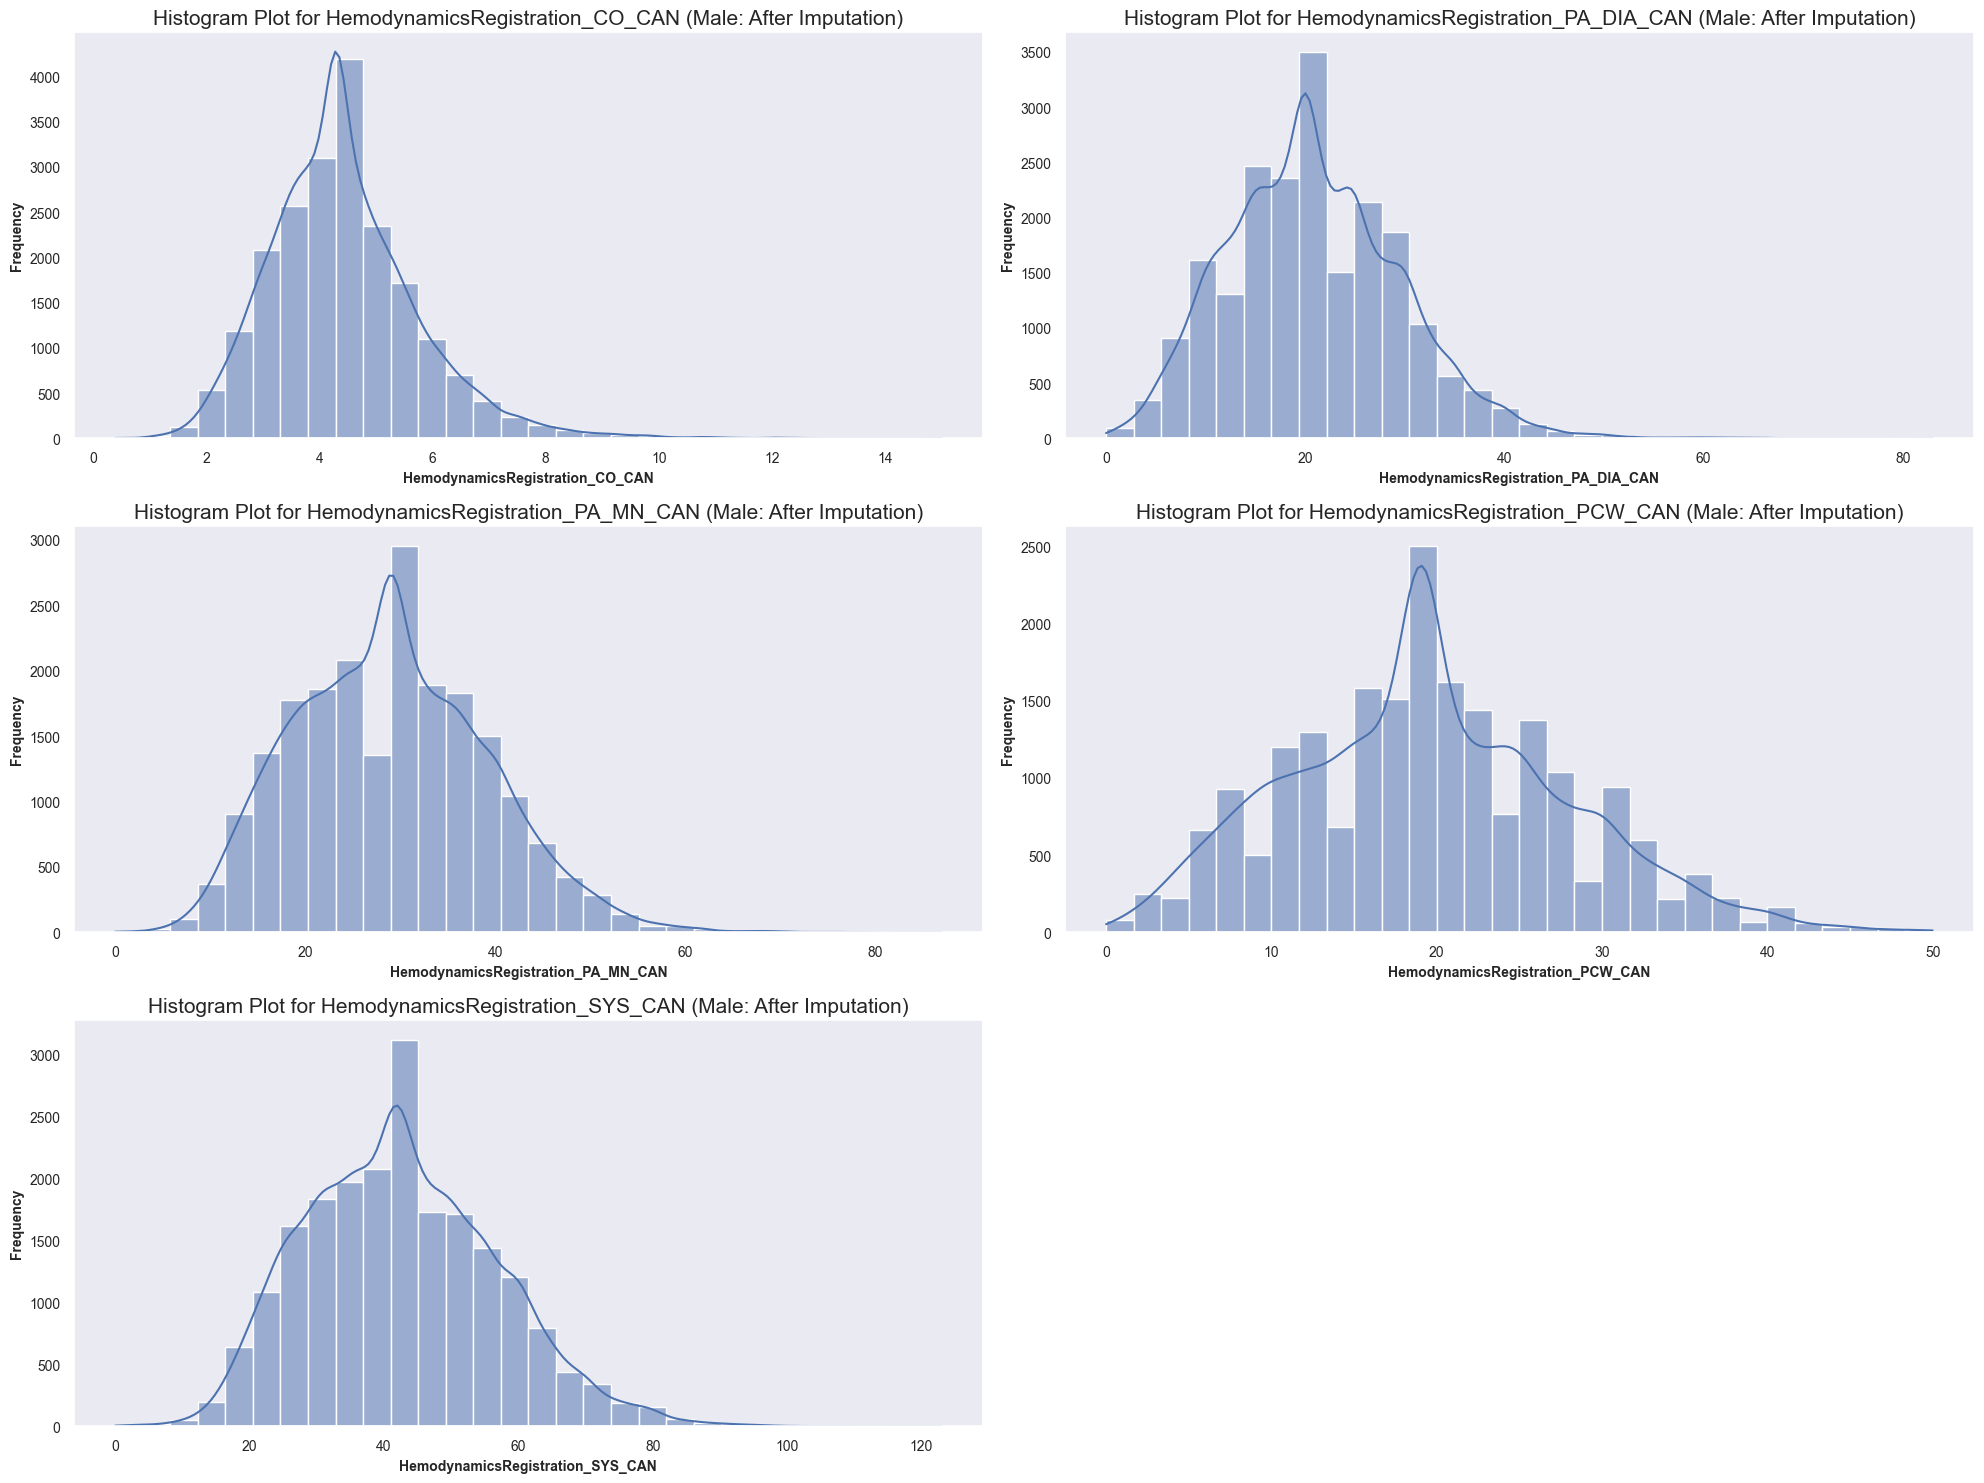

In [26]:
plot.plot_histogram(df_m, features, bins=30, txt='(Male: After Imputation)')

#### **Note:** Use PCA for hemodynamic variables since there are some features that are highly correlated.

In [27]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# scale for PCA
X_scaled = StandardScaler().fit_transform(df_m[features].values)

# PCA
pca = PCA(n_components=0.9, random_state=SEED).fit(X_scaled)  # 90% variance
print(f"Components: {pca.n_components_}")
print(f"Explained variance: {pca.explained_variance_ratio_}")

# Add to dataframe
pca_scores = pca.transform(X_scaled)
for i in range(pca.n_components_):
    df_m[f'PC{i+1}_hemo_registration'] = pca_scores[:, i]

# drop columns
df_m = df_m.drop(columns=features)
# shape
df_m.shape

Components: 3
Explained variance: [0.706923   0.18666591 0.05527068]


(20737, 129)

#### Female

In [28]:
# info
features = u.get_feature_info(df_f, 'HemodynamicsRegistration', cat=False)

                                      count       mean        std   min      25%    50%   75%    max
HemodynamicsRegistration_CO_CAN      7148.0   3.822310   1.222956  0.91   2.9875   3.69   4.5   15.0
HemodynamicsRegistration_PA_DIA_CAN  7273.0  19.717311   8.370123  0.00  14.0000  19.00  25.0   91.0
HemodynamicsRegistration_PA_MN_CAN   7231.0  27.628244   9.838857  4.00  20.0000  27.00  34.0   96.0
HemodynamicsRegistration_PCW_CAN     6883.0  18.111652   8.433316  0.00  12.0000  18.00  24.0   50.0
HemodynamicsRegistration_SYS_CAN     7277.0  40.551326  13.553369  0.00  31.0000  40.00  50.0  130.0

:::: NaN Count:
HemodynamicsRegistration_CO_CAN        441
HemodynamicsRegistration_PA_DIA_CAN    316
HemodynamicsRegistration_PA_MN_CAN     358
HemodynamicsRegistration_PCW_CAN       706
HemodynamicsRegistration_SYS_CAN       312 



In [29]:
df_f[features].corr()

,HemodynamicsRegistration_CO_CAN,HemodynamicsRegistration_PA_DIA_CAN,HemodynamicsRegistration_PA_MN_CAN,HemodynamicsRegistration_PCW_CAN,HemodynamicsRegistration_SYS_CAN
HemodynamicsRegistration_CO_CAN,1.000000,-0.205351,-0.178502,-0.235942,-0.129223
HemodynamicsRegistration_PA_DIA_CAN,-0.205351,1.000000,0.883735,0.823780,0.788469
HemodynamicsRegistration_PA_MN_CAN,-0.178502,0.883735,1.000000,0.828155,0.909364
HemodynamicsRegistration_PCW_CAN,-0.235942,0.823780,0.828155,1.000000,0.752129
HemodynamicsRegistration_SYS_CAN,-0.129223,0.788469,0.909364,0.752129,1.000000


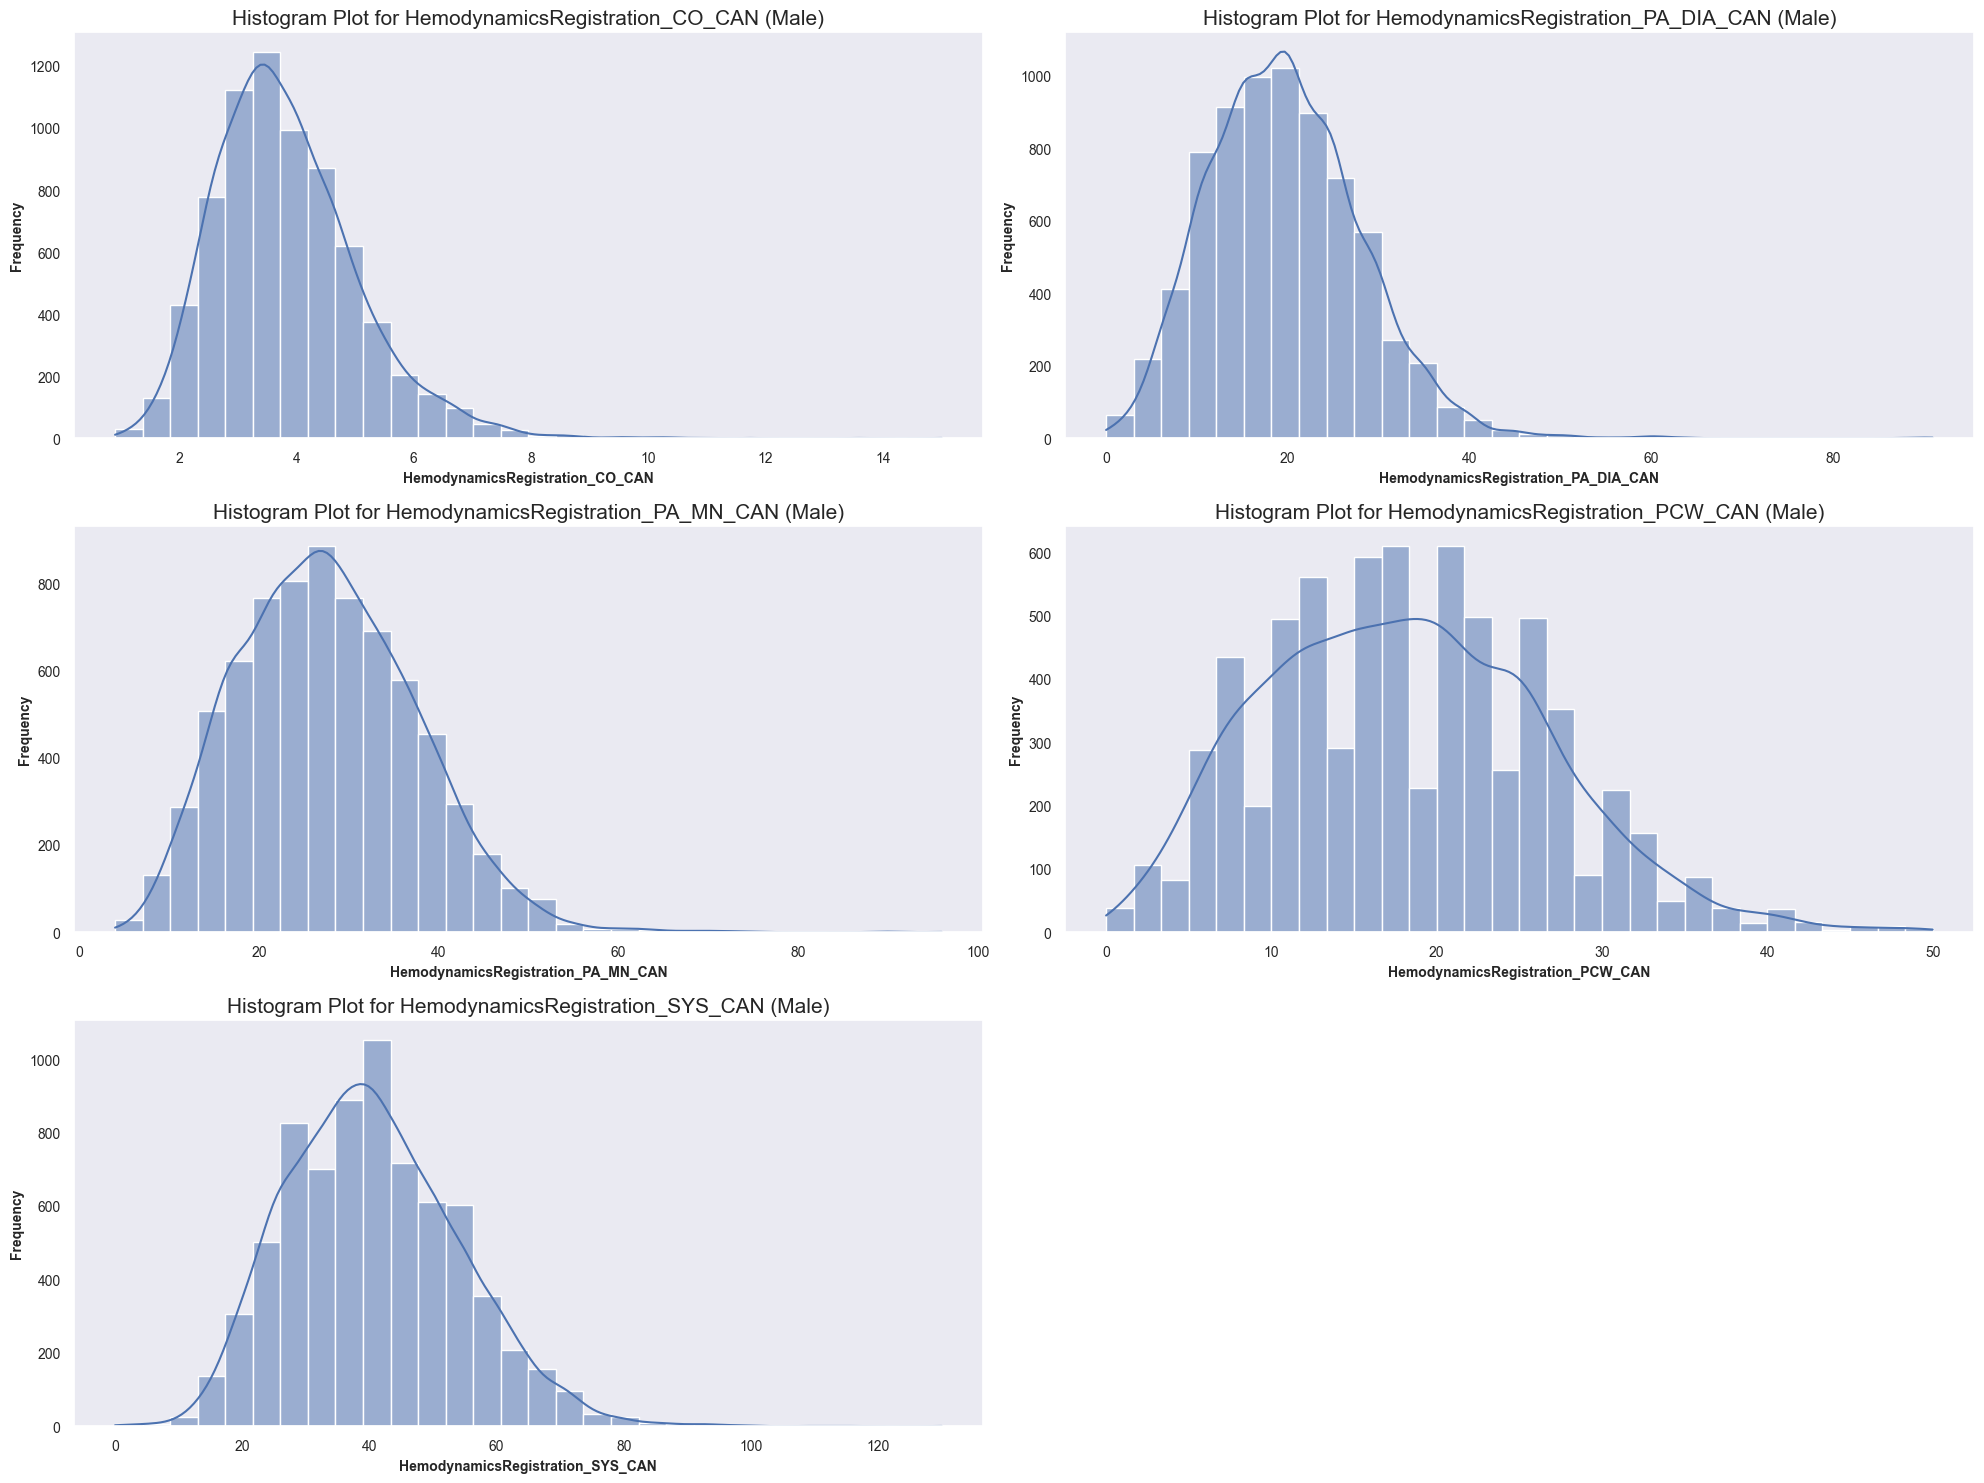

In [30]:
plot.plot_histogram(df_f, features, bins=30, txt='(Male)')

In [31]:
u.check_informative_missingness(df_f, 'HemodynamicsRegistration_CO_CAN', txt='Female')

--- Missingness (Female): HemodynamicsRegistration_CO_CAN ---
Group Sizes:    (Unknown=441, Known=7,148)
Mean survival:  (Unknown=1,349.6d, Known=1,330.7d)
Difference:     18.9 days

--- Welch's t-test Analysis ---
ρ-Value: 0.7300
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     0.0177 (Negligible)
95% CI:        [-0.0785, 0.1139]
Result: Likely Random Missingness (Effect size not significant)



In [32]:
u.continuous_value_predicts_survival(df_f, 'HemodynamicsRegistration_CO_CAN', txt='Female')

--- Value Predicts Survival (Female): HemodynamicsRegistration_CO_CAN ---
Pearson r=-0.022, p=0.06854 & Approx. Variance Explained=0.046%
Spearman r=-0.019, p=0.1087 & Approx. Variance Explained=0.036%



#### Median Imputation

In [33]:
# Median impute
df_f['HemodynamicsRegistration_CO_CAN'] = df_f['HemodynamicsRegistration_CO_CAN'].fillna(
    df_f['HemodynamicsRegistration_CO_CAN'].median()
)

In [34]:
u.check_informative_missingness(df_f, 'HemodynamicsRegistration_PA_DIA_CAN', txt='Female')

--- Missingness (Female): HemodynamicsRegistration_PA_DIA_CAN ---
Group Sizes:    (Unknown=316, Known=7,273)
Mean survival:  (Unknown=1,296.1d, Known=1,333.4d)
Difference:     -37.3 days

--- Welch's t-test Analysis ---
ρ-Value: 0.5670
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     -0.0349 (Negligible)
95% CI:        [-0.1475, 0.0777]
Result: Likely Random Missingness (Effect size not significant)



In [35]:
u.continuous_value_predicts_survival(df_f, 'HemodynamicsRegistration_PA_DIA_CAN', txt='Female')

--- Value Predicts Survival (Female): HemodynamicsRegistration_PA_DIA_CAN ---
Pearson r=0.042, p=0.0003465 & Approx. Variance Explained=0.176%
Spearman r=0.041, p=0.0004923 & Approx. Variance Explained=0.167%



#### Median Imputation

In [36]:
# Median impute
df_f['HemodynamicsRegistration_PA_DIA_CAN'] = df_f['HemodynamicsRegistration_PA_DIA_CAN'].fillna(
    df_f['HemodynamicsRegistration_PA_DIA_CAN'].median()
)

In [37]:
u.check_informative_missingness(df_f, 'HemodynamicsRegistration_PA_MN_CAN', txt='Female')

--- Missingness (Female): HemodynamicsRegistration_PA_MN_CAN ---
Group Sizes:    (Unknown=358, Known=7,231)
Mean survival:  (Unknown=1,425.5d, Known=1,327.2d)
Difference:     98.4 days

--- Welch's t-test Analysis ---
ρ-Value: 0.1260
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     0.0920 (Negligible)
95% CI:        [-0.0141, 0.1982]
Result: Likely Random Missingness (Effect size not significant)



#### Median Imputation

In [38]:
# Median impute
df_f['HemodynamicsRegistration_PA_MN_CAN'] = df_f['HemodynamicsRegistration_PA_MN_CAN'].fillna(
    df_f['HemodynamicsRegistration_PA_MN_CAN'].median()
)

In [39]:
u.check_informative_missingness(df_f, 'HemodynamicsRegistration_PCW_CAN', txt='Female')

--- Missingness (Female): HemodynamicsRegistration_PCW_CAN ---
Group Sizes:    (Unknown=706, Known=6,883)
Mean survival:  (Unknown=1,371.3d, Known=1,327.7d)
Difference:     43.6 days

--- Welch's t-test Analysis ---
ρ-Value: 0.3236
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     0.0408 (Negligible)
95% CI:        [-0.0367, 0.1183]
Result: Likely Random Missingness (Effect size not significant)



#### Median Imputation

In [40]:
# Median impute
df_f['HemodynamicsRegistration_PCW_CAN'] = df_f['HemodynamicsRegistration_PCW_CAN'].fillna(
    df_f['HemodynamicsRegistration_PCW_CAN'].median()
)

In [41]:
u.check_informative_missingness(df_f, 'HemodynamicsRegistration_SYS_CAN', txt='Female')

--- Missingness (Female): HemodynamicsRegistration_SYS_CAN ---
Group Sizes:    (Unknown=312, Known=7,277)
Mean survival:  (Unknown=1,293.8d, Known=1,333.4d)
Difference:     -39.7 days

--- Welch's t-test Analysis ---
ρ-Value: 0.5421
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     -0.0371 (Negligible)
95% CI:        [-0.1504, 0.0762]
Result: Likely Random Missingness (Effect size not significant)



#### Median Imputation

In [42]:
# Median impute
df_f['HemodynamicsRegistration_SYS_CAN'] = df_f['HemodynamicsRegistration_SYS_CAN'].fillna(
    df_f['HemodynamicsRegistration_SYS_CAN'].median()
)

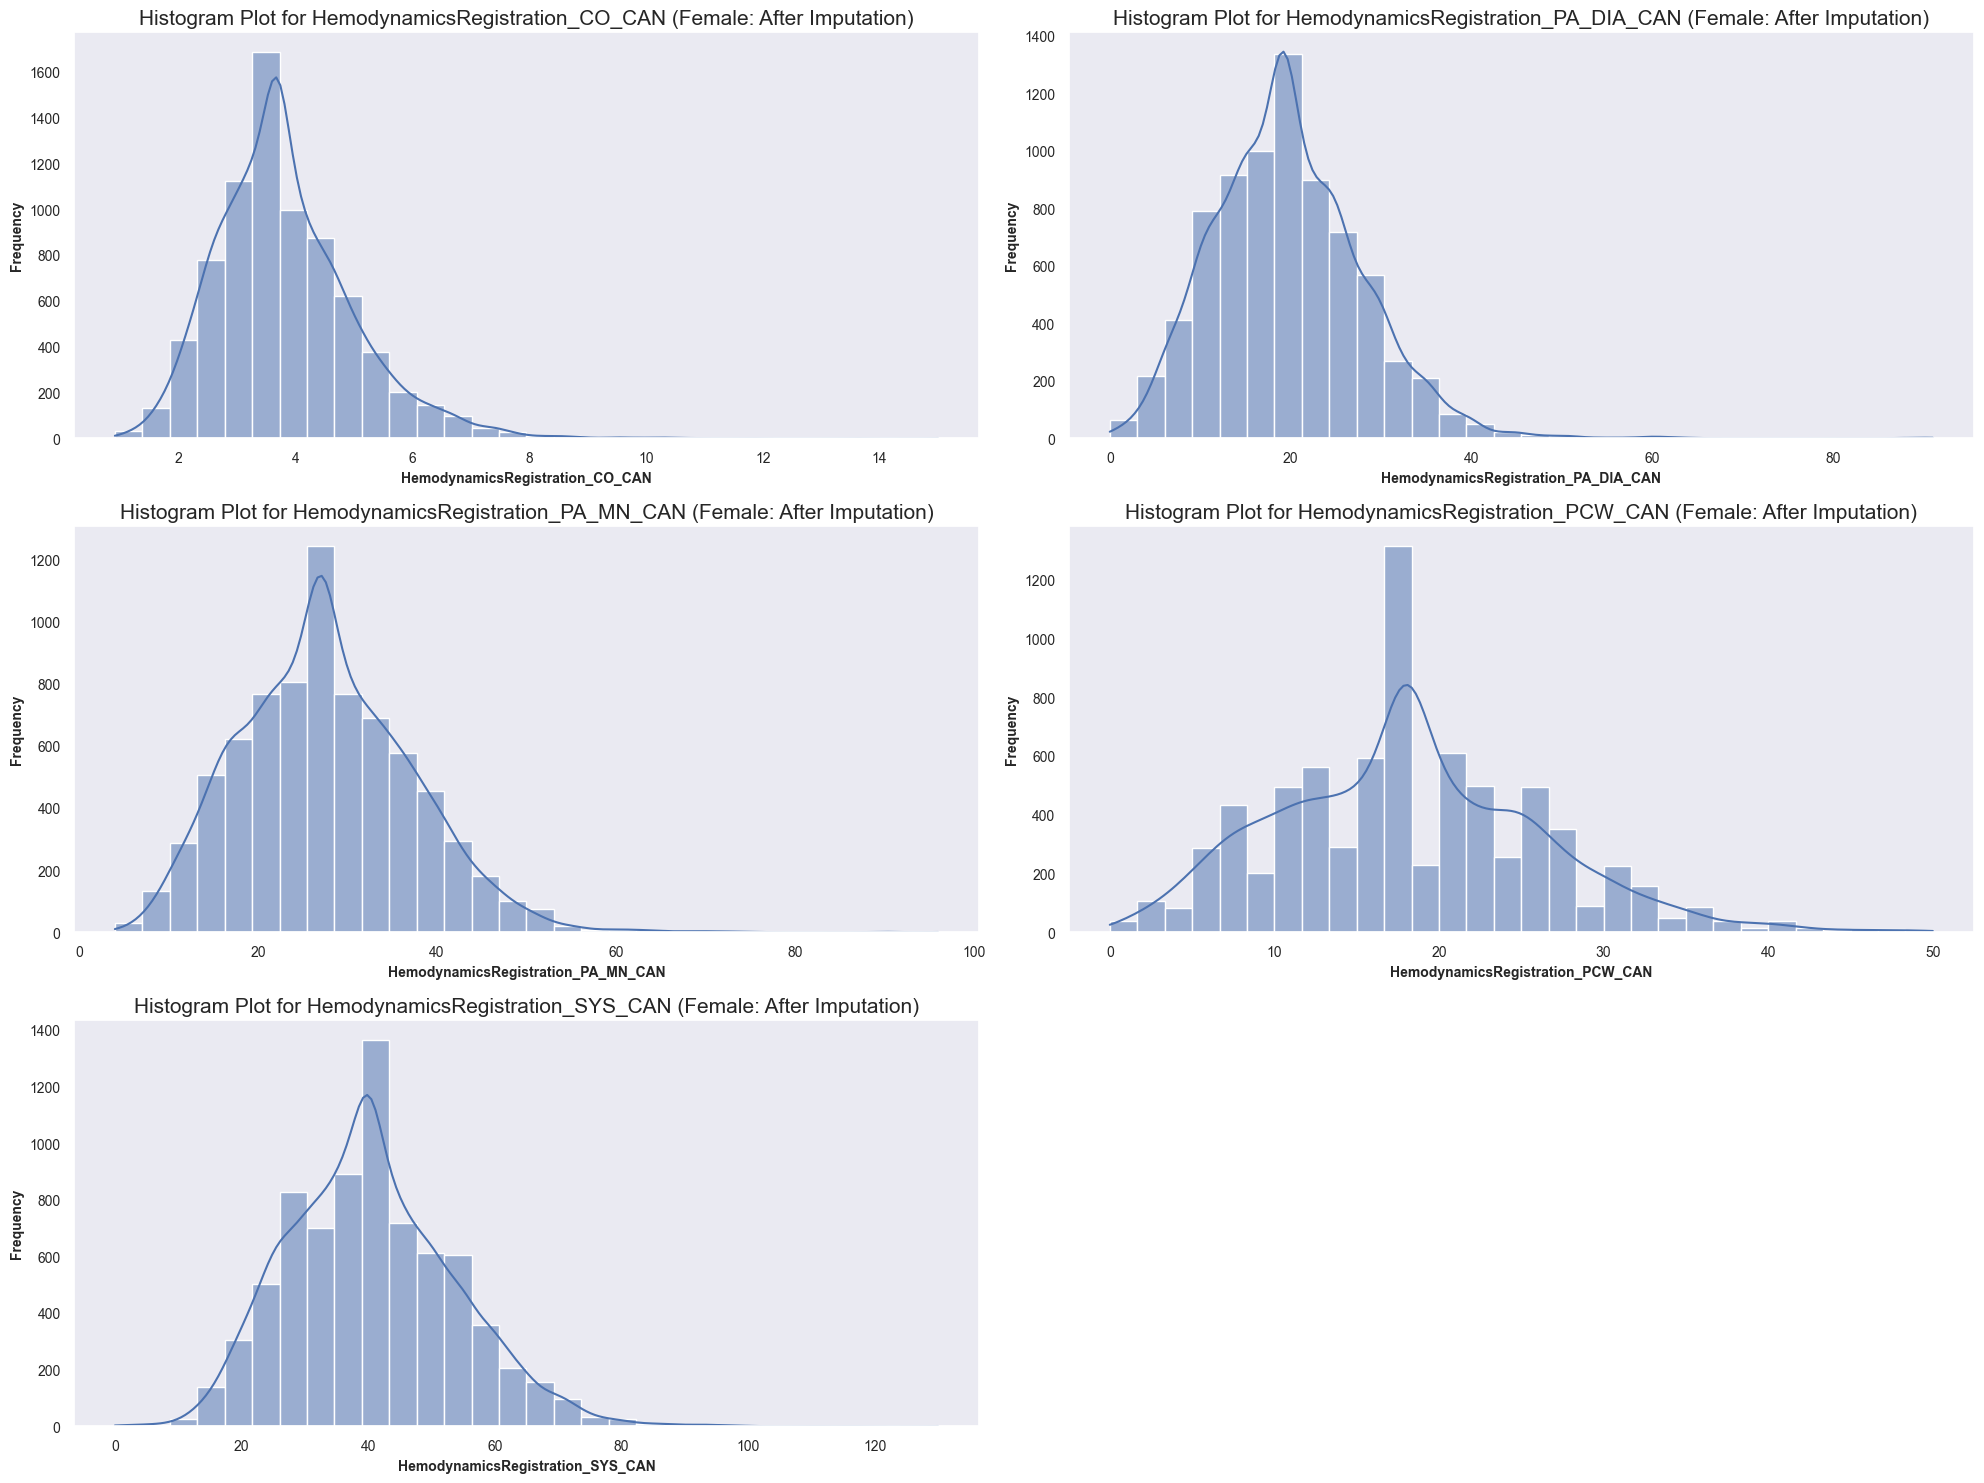

In [43]:
plot.plot_histogram(df_f, features, bins=30, txt='(Female: After Imputation)')

In [44]:
# scale for PCA
X_scaled = StandardScaler().fit_transform(df_f[features].values)

# PCA
pca = PCA(n_components=0.9, random_state=SEED).fit(X_scaled)  # 90% variance
print(f"Components: {pca.n_components_}")
print(f"Explained variance: {pca.explained_variance_ratio_}")

# Add to dataframe
pca_scores = pca.transform(X_scaled)
for i in range(pca.n_components_):
    df_f[f'PC{i+1}_hemo_registration'] = pca_scores[:, i]

# drop columns
df_f = df_f.drop(columns=features)
# shape
df_f.shape

Components: 3
Explained variance: [0.69717465 0.19133644 0.05738098]


(7589, 127)

## Hemodynamics Transplant

#### Male

In [45]:
# info
features = u.get_feature_info(df_m, 'HemodynamicsTransplant', cat=False)

                                     count       mean        std  min   25%    50%   75%    max
HemodynamicsTransplant_CO_CAN      19868.0   4.715230   1.465477  0.2   3.7   4.55   5.5   15.0
HemodynamicsTransplant_PA_DIA_CAN  20192.0  19.339402   8.562328  0.0  13.0  18.00  25.0  110.0
HemodynamicsTransplant_PA_MN_CAN   19989.0  27.233478  10.006183  0.0  20.0  26.00  34.0  110.0
HemodynamicsTransplant_PCW_CAN     19246.0  18.035215   8.756555  0.0  11.0  17.00  24.0   50.0
HemodynamicsTransplant_SYS_CAN     20207.0  40.092641  13.984482  1.0  30.0  38.00  49.0  159.0

:::: NaN Count:
HemodynamicsTransplant_CO_CAN         869
HemodynamicsTransplant_PA_DIA_CAN     545
HemodynamicsTransplant_PA_MN_CAN      748
HemodynamicsTransplant_PCW_CAN       1491
HemodynamicsTransplant_SYS_CAN        530 



In [46]:
df_m[features].corr()

,HemodynamicsTransplant_CO_CAN,HemodynamicsTransplant_PA_DIA_CAN,HemodynamicsTransplant_PA_MN_CAN,HemodynamicsTransplant_PCW_CAN,HemodynamicsTransplant_SYS_CAN
HemodynamicsTransplant_CO_CAN,1.000000,-0.237909,-0.206392,-0.239612,-0.177014
HemodynamicsTransplant_PA_DIA_CAN,-0.237909,1.000000,0.904482,0.822103,0.794961
HemodynamicsTransplant_PA_MN_CAN,-0.206392,0.904482,1.000000,0.834541,0.918454
HemodynamicsTransplant_PCW_CAN,-0.239612,0.822103,0.834541,1.000000,0.764728
HemodynamicsTransplant_SYS_CAN,-0.177014,0.794961,0.918454,0.764728,1.000000


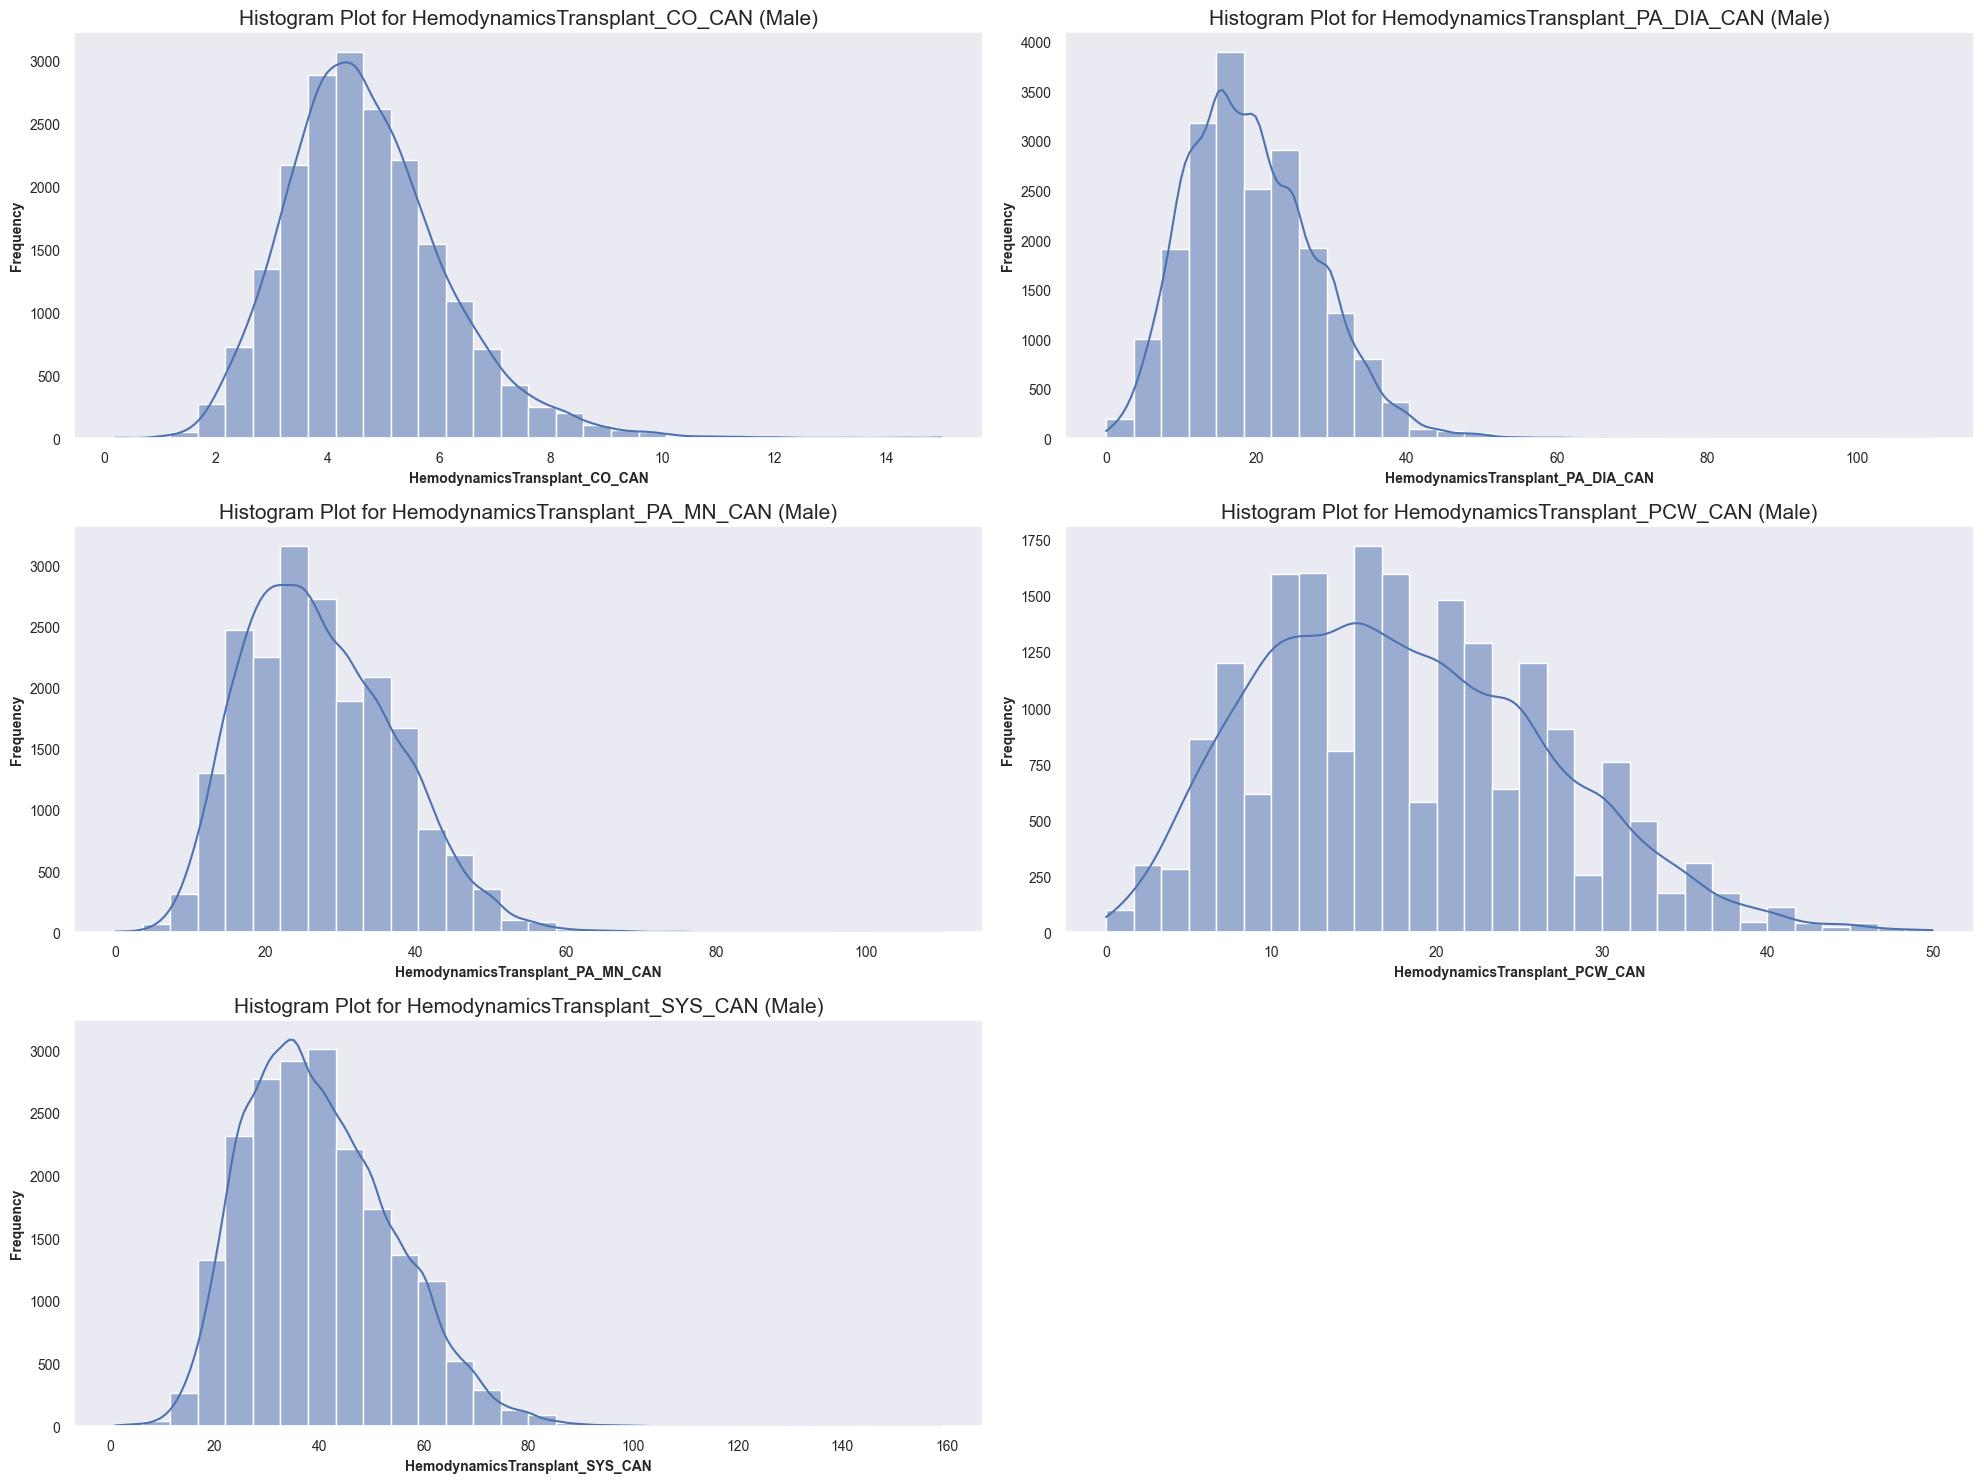

In [47]:
plot.plot_histogram(df_m, features, bins=30, txt='(Male)')

In [48]:
u.check_informative_missingness(df_m, 'HemodynamicsTransplant_CO_CAN', txt='Male')

--- Missingness (Male): HemodynamicsTransplant_CO_CAN ---
Group Sizes:    (Unknown=869, Known=19,868)
Mean survival:  (Unknown=1,096.3d, Known=1,339.7d)
Difference:     -243.4 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0000
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.2294 (Small)
95% CI:        [-0.2974, -0.1615]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



In [49]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsTransplant_CO_CAN', txt='Male')

--- Value Predicts Survival (Male): HemodynamicsTransplant_CO_CAN ---
Pearson r=0.018, p=0.01106 & Approx. Variance Explained=0.032%
Spearman r=0.028, p=8.965e-05 & Approx. Variance Explained=0.077%



#### The "Shadow Variable" (Indicator) + Median Imputation

In [50]:
# impute: median and use new feature for NANS
df_m['HemodynamicsTransplant_CO_Ismissing'] = df_m['HemodynamicsTransplant_CO_CAN'].isna().astype(int)
df_m['HemodynamicsTransplant_CO_CAN'] = df_m['HemodynamicsTransplant_CO_CAN'].fillna(
    df_m['HemodynamicsTransplant_CO_CAN'].median()
)

In [51]:
u.check_informative_missingness(df_m, 'HemodynamicsTransplant_PA_DIA_CAN', txt='Male')

--- Missingness (Male): HemodynamicsTransplant_PA_DIA_CAN ---
Group Sizes:    (Unknown=545, Known=20,192)
Mean survival:  (Unknown=1,035.9d, Known=1,337.4d)
Difference:     -301.6 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0000
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.2843 (Small)
95% CI:        [-0.3694, -0.1991]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



In [52]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsTransplant_PA_DIA_CAN', txt='Male')

--- Value Predicts Survival (Male): HemodynamicsTransplant_PA_DIA_CAN ---
Pearson r=-0.023, p=0.001322 & Approx. Variance Explained=0.051%
Spearman r=-0.026, p=0.0001837 & Approx. Variance Explained=0.069%



#### The "Shadow Variable" (Indicator) + Median Imputation

In [53]:
# impute: median and use new feature for NANS
df_m['HemodynamicsTransplant_PA_DIA_Ismissing'] = df_m['HemodynamicsTransplant_PA_DIA_CAN'].isna().astype(int)
df_m['HemodynamicsTransplant_PA_DIA_CAN'] = df_m['HemodynamicsTransplant_PA_DIA_CAN'].fillna(
    df_m['HemodynamicsTransplant_PA_DIA_CAN'].median()
)

In [54]:
u.check_informative_missingness(df_m, 'HemodynamicsTransplant_PA_MN_CAN', txt='Male')

--- Missingness (Male): HemodynamicsTransplant_PA_MN_CAN ---
Group Sizes:    (Unknown=748, Known=19,989)
Mean survival:  (Unknown=1,163.2d, Known=1,335.7d)
Difference:     -172.5 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0000
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.1625 (Negligible)
95% CI:        [-0.2355, -0.0895]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



In [55]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsTransplant_PA_MN_CAN', txt='Male')

--- Value Predicts Survival (Male): HemodynamicsTransplant_PA_MN_CAN ---
Pearson r=-0.010, p=0.1609 & Approx. Variance Explained=0.010%
Spearman r=-0.015, p=0.03085 & Approx. Variance Explained=0.023%



#### The "Shadow Variable" (Indicator) + Median Imputation

In [56]:
# impute: median and use new feature for NANS
df_m['HemodynamicsTransplant_PA_MN_Ismissing'] = df_m['HemodynamicsTransplant_PA_MN_CAN'].isna().astype(int)
df_m['HemodynamicsTransplant_PA_MN_CAN'] = df_m['HemodynamicsTransplant_PA_MN_CAN'].fillna(
    df_m['HemodynamicsTransplant_PA_MN_CAN'].median()
)

In [57]:
u.check_informative_missingness(df_m, 'HemodynamicsTransplant_PCW_CAN', txt='Male')

--- Missingness (Male): HemodynamicsTransplant_PCW_CAN ---
Group Sizes:    (Unknown=1,491, Known=19,246)
Mean survival:  (Unknown=1,154.3d, Known=1,343.1d)
Difference:     -188.8 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0000
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.1780 (Negligible)
95% CI:        [-0.2307, -0.1253]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



In [58]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsTransplant_PCW_CAN', txt='Male')

--- Value Predicts Survival (Male): HemodynamicsTransplant_PCW_CAN ---
Pearson r=-0.007, p=0.3513 & Approx. Variance Explained=0.005%
Spearman r=-0.013, p=0.06841 & Approx. Variance Explained=0.017%



#### The "Shadow Variable" (Indicator) + Median Imputation

In [59]:
# impute: median and use new feature for NANS
df_m['HemodynamicsTransplant_PCW_Ismissing'] = df_m['HemodynamicsTransplant_PCW_CAN'].isna().astype(int)
df_m['HemodynamicsTransplant_PCW_CAN'] = df_m['HemodynamicsTransplant_PCW_CAN'].fillna(
    df_m['HemodynamicsTransplant_PCW_CAN'].median()
)

In [60]:
u.check_informative_missingness(df_m, 'HemodynamicsTransplant_SYS_CAN', txt='Male')

--- Missingness (Male): HemodynamicsTransplant_SYS_CAN ---
Group Sizes:    (Unknown=530, Known=20,207)
Mean survival:  (Unknown=1,018.8d, Known=1,337.7d)
Difference:     -318.8 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0000
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.3005 (Small)
95% CI:        [-0.3868, -0.2142]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



In [61]:
u.continuous_value_predicts_survival(df_m, 'HemodynamicsTransplant_SYS_CAN', txt='Male')

--- Value Predicts Survival (Male): HemodynamicsTransplant_SYS_CAN ---
Pearson r=-0.003, p=0.6652 & Approx. Variance Explained=0.001%
Spearman r=-0.011, p=0.1106 & Approx. Variance Explained=0.013%



#### The "Shadow Variable" (Indicator) + Median Imputation

In [62]:
# impute: median and use new feature for NANS
df_m['HemodynamicsTransplant_SYS_Ismissing'] = df_m['HemodynamicsTransplant_SYS_CAN'].isna().astype(int)
df_m['HemodynamicsTransplant_SYS_CAN'] = df_m['HemodynamicsTransplant_SYS_CAN'].fillna(
    df_m['HemodynamicsTransplant_SYS_CAN'].median()
)

#### Female

In [63]:
# info
features = u.get_feature_info(df_f, 'HemodynamicsTransplant', cat=False)

                                    count       mean        std  min    25%   50%   75%    max
HemodynamicsTransplant_CO_CAN      7218.0   4.051886   1.319523  0.2   3.13   3.9   4.8   15.0
HemodynamicsTransplant_PA_DIA_CAN  7332.0  18.608702   8.208180  0.0  13.00  18.0  24.0   65.0
HemodynamicsTransplant_PA_MN_CAN   7273.0  26.384200   9.656789  0.0  19.00  25.0  33.0   88.0
HemodynamicsTransplant_PCW_CAN     7030.0  17.022397   8.400556  0.0  10.00  16.0  23.0   50.0
HemodynamicsTransplant_SYS_CAN     7337.0  38.752051  13.291202  0.0  29.00  37.0  47.0  127.0

:::: NaN Count:
HemodynamicsTransplant_CO_CAN        371
HemodynamicsTransplant_PA_DIA_CAN    257
HemodynamicsTransplant_PA_MN_CAN     316
HemodynamicsTransplant_PCW_CAN       559
HemodynamicsTransplant_SYS_CAN       252 



In [64]:
df_f[features].corr()

,HemodynamicsTransplant_CO_CAN,HemodynamicsTransplant_PA_DIA_CAN,HemodynamicsTransplant_PA_MN_CAN,HemodynamicsTransplant_PCW_CAN,HemodynamicsTransplant_SYS_CAN
HemodynamicsTransplant_CO_CAN,1.000000,-0.207517,-0.173649,-0.228658,-0.140496
HemodynamicsTransplant_PA_DIA_CAN,-0.207517,1.000000,0.891131,0.812089,0.779296
HemodynamicsTransplant_PA_MN_CAN,-0.173649,0.891131,1.000000,0.825614,0.912886
HemodynamicsTransplant_PCW_CAN,-0.228658,0.812089,0.825614,1.000000,0.748660
HemodynamicsTransplant_SYS_CAN,-0.140496,0.779296,0.912886,0.748660,1.000000


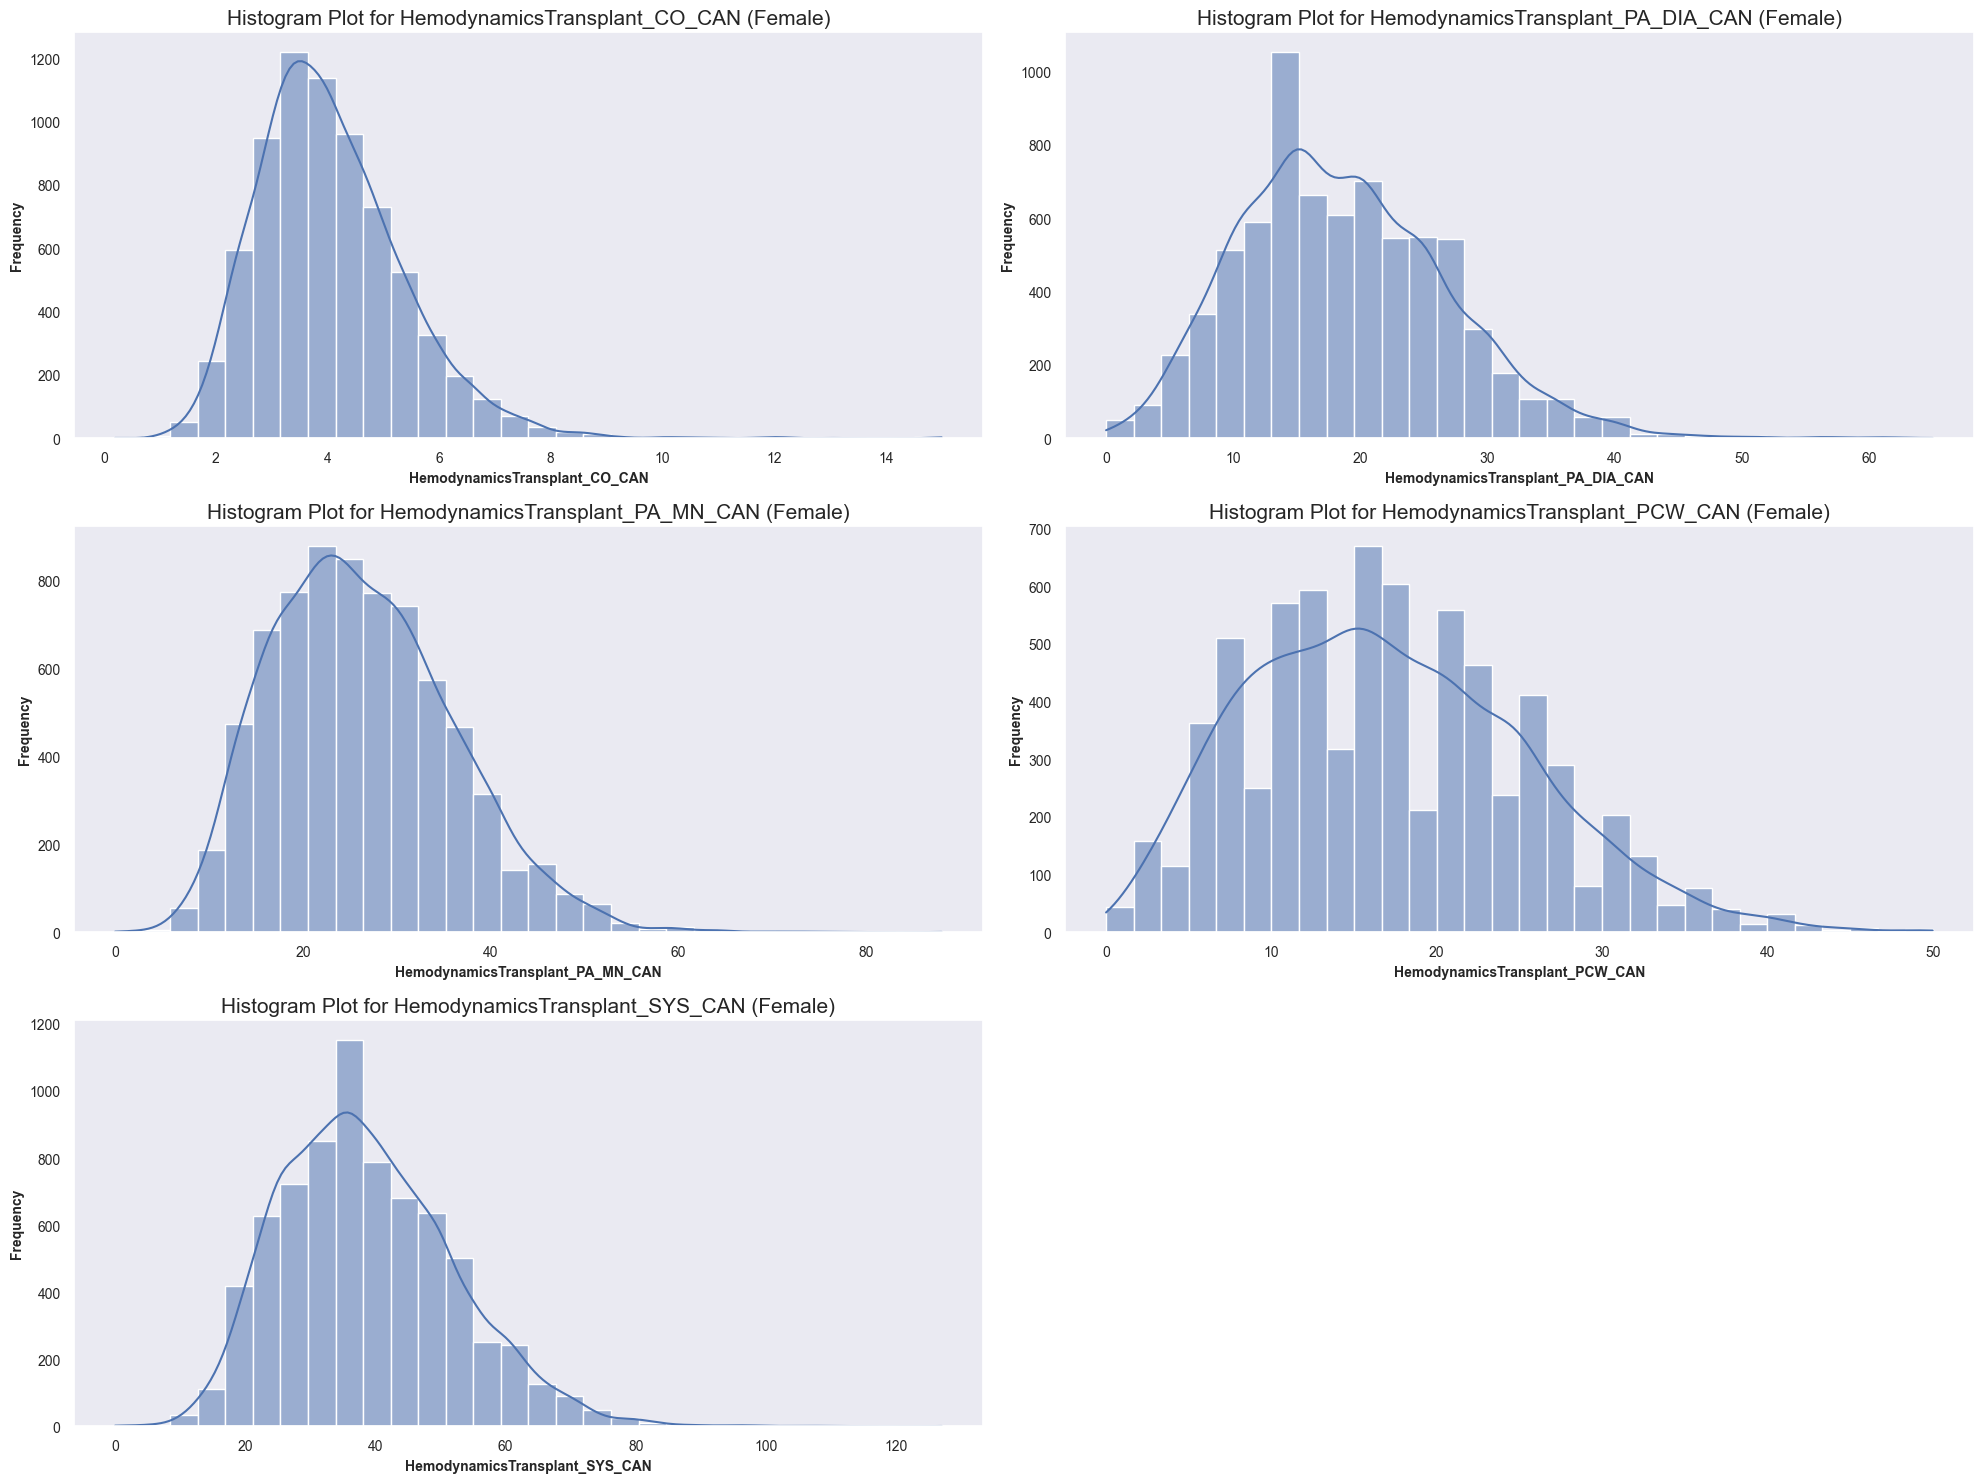

In [65]:
plot.plot_histogram(df_f, features, bins=30, txt='(Female)')

In [66]:
u.check_informative_missingness(df_f, 'HemodynamicsTransplant_CO_CAN', txt='Female')

--- Missingness (Female): HemodynamicsTransplant_CO_CAN ---
Group Sizes:    (Unknown=371, Known=7,218)
Mean survival:  (Unknown=1,272.0d, Known=1,334.9d)
Difference:     -62.8 days

--- Welch's t-test Analysis ---
ρ-Value: 0.3054
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     -0.0588 (Negligible)
95% CI:        [-0.1631, 0.0455]
Result: Likely Random Missingness (Effect size not significant)



In [67]:
u.continuous_value_predicts_survival(df_f, 'HemodynamicsTransplant_CO_CAN', txt='Female')

--- Value Predicts Survival (Female): HemodynamicsTransplant_CO_CAN ---
Pearson r=-0.023, p=0.04912 & Approx. Variance Explained=0.054%
Spearman r=-0.015, p=0.1996 & Approx. Variance Explained=0.023%



#### Median Imputation

In [68]:
# Median impute
df_f['HemodynamicsTransplant_CO_CAN'] = df_f['HemodynamicsTransplant_CO_CAN'].fillna(
    df_f['HemodynamicsTransplant_CO_CAN'].median()
)

In [69]:
u.check_informative_missingness(df_f, 'HemodynamicsTransplant_PA_DIA_CAN', txt='Female')

--- Missingness (Female): HemodynamicsTransplant_PA_DIA_CAN ---
Group Sizes:    (Unknown=257, Known=7,332)
Mean survival:  (Unknown=1,213.8d, Known=1,335.9d)
Difference:     -122.1 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0950
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     -0.1143 (Negligible)
95% CI:        [-0.2387, 0.0101]
Result: Likely Random Missingness (Effect size not significant)



In [70]:
u.continuous_value_predicts_survival(df_f, 'HemodynamicsTransplant_PA_DIA_CAN', txt='Female')

--- Value Predicts Survival (Female): HemodynamicsTransplant_PA_DIA_CAN ---
Pearson r=0.012, p=0.3219 & Approx. Variance Explained=0.013%
Spearman r=-0.001, p=0.9252 & Approx. Variance Explained=0.000%



#### Median Imputation

In [71]:
# Median impute
df_f['HemodynamicsTransplant_PA_DIA_CAN'] = df_f['HemodynamicsTransplant_PA_DIA_CAN'].fillna(
    df_f['HemodynamicsTransplant_PA_DIA_CAN'].median()
)

In [72]:
u.check_informative_missingness(df_f, 'HemodynamicsTransplant_PA_MN_CAN', txt='Female')

--- Missingness (Female): HemodynamicsTransplant_PA_MN_CAN ---
Group Sizes:    (Unknown=316, Known=7,273)
Mean survival:  (Unknown=1,241.3d, Known=1,335.7d)
Difference:     -94.5 days

--- Welch's t-test Analysis ---
ρ-Value: 0.1536
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     -0.0884 (Negligible)
95% CI:        [-0.2010, 0.0242]
Result: Likely Random Missingness (Effect size not significant)



In [73]:
u.continuous_value_predicts_survival(df_f, 'HemodynamicsTransplant_PA_MN_CAN', txt='Female')

--- Value Predicts Survival (Female): HemodynamicsTransplant_PA_MN_CAN ---
Pearson r=0.023, p=0.04741 & Approx. Variance Explained=0.054%
Spearman r=0.009, p=0.442 & Approx. Variance Explained=0.008%



#### Median Imputation

In [74]:
# Median impute
df_f['HemodynamicsTransplant_PA_MN_CAN'] = df_f['HemodynamicsTransplant_PA_MN_CAN'].fillna(
    df_f['HemodynamicsTransplant_PA_MN_CAN'].median()
)

In [75]:
u.check_informative_missingness(df_f, 'HemodynamicsTransplant_PCW_CAN', txt='Female')

--- Missingness (Female): HemodynamicsTransplant_PCW_CAN ---
Group Sizes:    (Unknown=559, Known=7,030)
Mean survival:  (Unknown=1,220.6d, Known=1,340.6d)
Difference:     -120.0 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0131
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.1123 (Negligible)
95% CI:        [-0.1985, -0.0262]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



In [76]:
u.continuous_value_predicts_survival(df_f, 'HemodynamicsTransplant_PCW_CAN', txt='Female')

--- Value Predicts Survival (Female): HemodynamicsTransplant_PCW_CAN ---
Pearson r=0.015, p=0.1978 & Approx. Variance Explained=0.024%
Spearman r=0.007, p=0.5297 & Approx. Variance Explained=0.006%



#### The "Shadow Variable" (Indicator) + Median Imputation

In [77]:
# impute: median and use new feature for NANS
df_f['HemodynamicsTransplant_PCW_Ismissing'] = df_f['HemodynamicsTransplant_PCW_CAN'].isna().astype(int)
df_f['HemodynamicsTransplant_PCW_CAN'] = df_f['HemodynamicsTransplant_PCW_CAN'].fillna(
    df_f['HemodynamicsTransplant_PCW_CAN'].median()
)

In [78]:
u.check_informative_missingness(df_f, 'HemodynamicsTransplant_SYS_CAN', txt='Female')

--- Missingness (Female): HemodynamicsTransplant_SYS_CAN ---
Group Sizes:    (Unknown=252, Known=7,337)
Mean survival:  (Unknown=1,207.1d, Known=1,336.1d)
Difference:     -129.0 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0802
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     -0.1207 (Negligible)
95% CI:        [-0.2463, 0.0048]
Result: Likely Random Missingness (Effect size not significant)



In [79]:
u.continuous_value_predicts_survival(df_f, 'HemodynamicsTransplant_SYS_CAN', txt='Female')

--- Value Predicts Survival (Female): HemodynamicsTransplant_SYS_CAN ---
Pearson r=0.027, p=0.02178 & Approx. Variance Explained=0.072%
Spearman r=0.013, p=0.2521 & Approx. Variance Explained=0.018%



#### Median Imputation

In [80]:
# Median impute
df_f['HemodynamicsTransplant_SYS_CAN'] = df_f['HemodynamicsTransplant_SYS_CAN'].fillna(
    df_f['HemodynamicsTransplant_SYS_CAN'].median()
)

## Functional Status Registration

#### Male

In [81]:
# info
features = u.get_feature_info(df_m, 'FunctionalStatusRegistration', cat=False)

                                    count      mean       std  min  25%  50%  75%  max
FunctionalStatusRegistration_CAN  20047.0  0.469931  0.224865  0.1  0.2  0.5  0.7  1.0

:::: NaN Count:
FunctionalStatusRegistration_CAN    690 



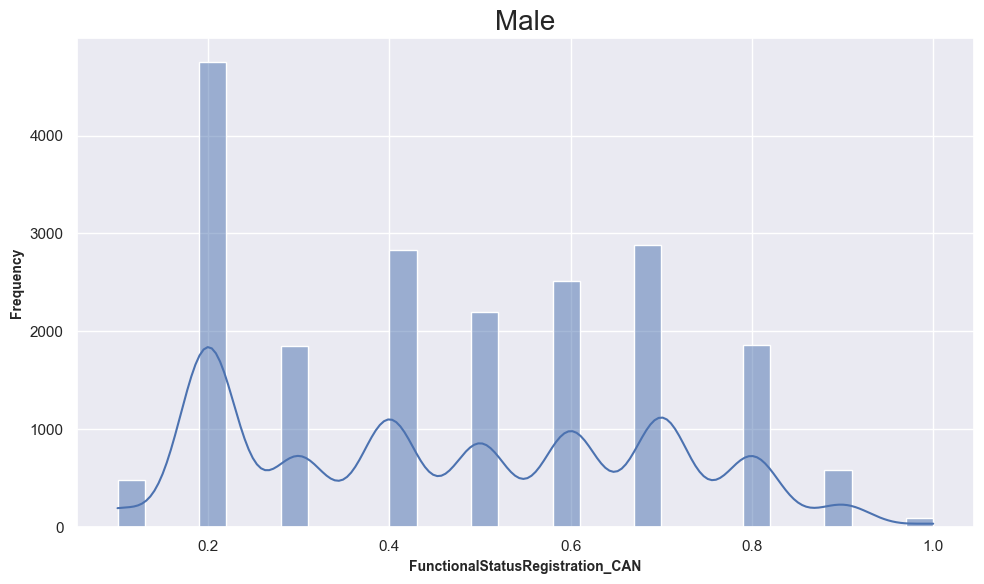

In [82]:
plot_histogram(df_m, 'FunctionalStatusRegistration_CAN', bins=30, txt='Male')

In [83]:
u.check_informative_missingness(df_m, 'FunctionalStatusRegistration_CAN', txt='Male')

--- Missingness (Male): FunctionalStatusRegistration_CAN ---
Group Sizes:    (Unknown=690, Known=20,047)
Mean survival:  (Unknown=1,136.8d, Known=1,336.1d)
Difference:     -199.3 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0000
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.1878 (Negligible)
95% CI:        [-0.2637, -0.1119]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



In [84]:
u.continuous_value_predicts_survival(df_m, 'FunctionalStatusRegistration_CAN', txt='Male')

--- Value Predicts Survival (Male): FunctionalStatusRegistration_CAN ---
Pearson r=0.117, p=1.691e-62 & Approx. Variance Explained=1.379%
Spearman r=0.117, p=2.316e-62 & Approx. Variance Explained=1.376%



#### The "Shadow Variable" (Indicator) + Median Imputation

In [85]:
# impute: median and use new feature for NANS
df_m['FunctionalStatusRegistration_Ismissing'] = df_m ['FunctionalStatusRegistration_CAN'].isna().astype(int)
df_m['FunctionalStatusRegistration_CAN'] = df_m['FunctionalStatusRegistration_CAN'].fillna(
    df_m['FunctionalStatusRegistration_CAN'].median()
)
# sanity check
df_m.FunctionalStatusRegistration_Ismissing.sum()

np.int64(690)

#### Female

In [86]:
# info
features = u.get_feature_info(df_f, 'FunctionalStatusRegistration', cat=False)

                                   count      mean       std  min  25%  50%  75%  max
FunctionalStatusRegistration_CAN  7327.0  0.471011  0.219268  0.1  0.2  0.5  0.7  1.0

:::: NaN Count:
FunctionalStatusRegistration_CAN    262 



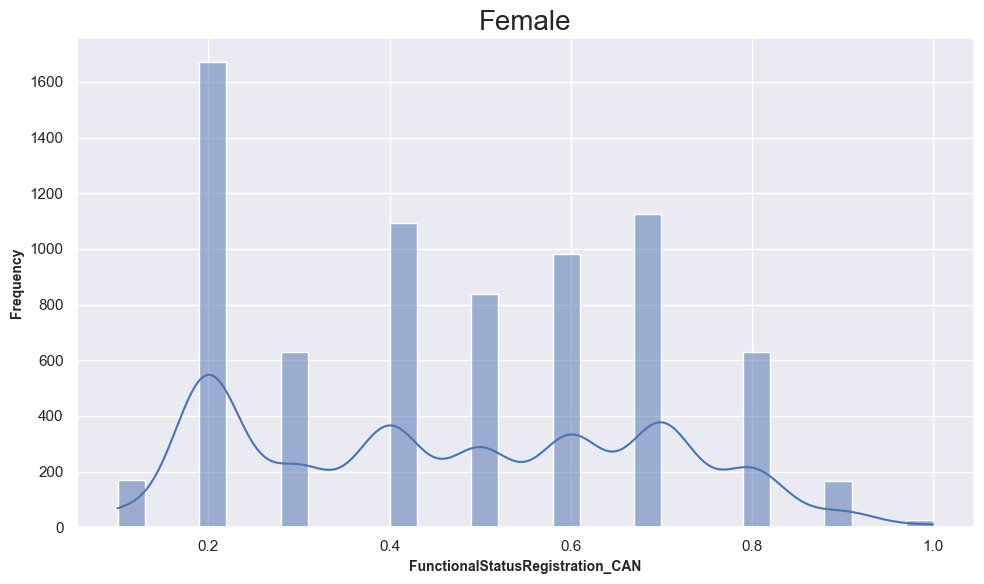

In [87]:
plot_histogram(df_f, 'FunctionalStatusRegistration_CAN', bins=30, txt='Female')

In [88]:
u.check_informative_missingness(df_f, 'FunctionalStatusRegistration_CAN', txt='Female')

--- Missingness (Female): FunctionalStatusRegistration_CAN ---
Group Sizes:    (Unknown=262, Known=7,327)
Mean survival:  (Unknown=1,172.5d, Known=1,337.5d)
Difference:     -165.0 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0120
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.1544 (Negligible)
95% CI:        [-0.2777, -0.0312]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



In [89]:
u.continuous_value_predicts_survival(df_f, 'FunctionalStatusRegistration_CAN', txt='Female')

--- Value Predicts Survival (Female): FunctionalStatusRegistration_CAN ---
Pearson r=0.122, p=7.166e-26 & Approx. Variance Explained=1.499%
Spearman r=0.123, p=4.139e-26 & Approx. Variance Explained=1.514%



#### The "Shadow Variable" (Indicator) + Median Imputation

In [90]:
# impute: median and use new feature for NANS
df_f['FunctionalStatusRegistration_Ismissing'] = df_f['FunctionalStatusRegistration_CAN'].isna().astype(int)
df_f['FunctionalStatusRegistration_CAN'] = df_f['FunctionalStatusRegistration_CAN'].fillna(
    df_f['FunctionalStatusRegistration_CAN'].median()
)

## Functional Status Transplant

In [91]:
# info
features = u.get_feature_info(df_m, 'FunctionalStatusTransplant', cat=False)

                                  count     mean       std  min  25%  50%  75%  max
FunctionalStatusTransplant_CAN  19773.0  0.43432  0.238572  0.1  0.2  0.4  0.6  1.0

:::: NaN Count:
FunctionalStatusTransplant_CAN    964 



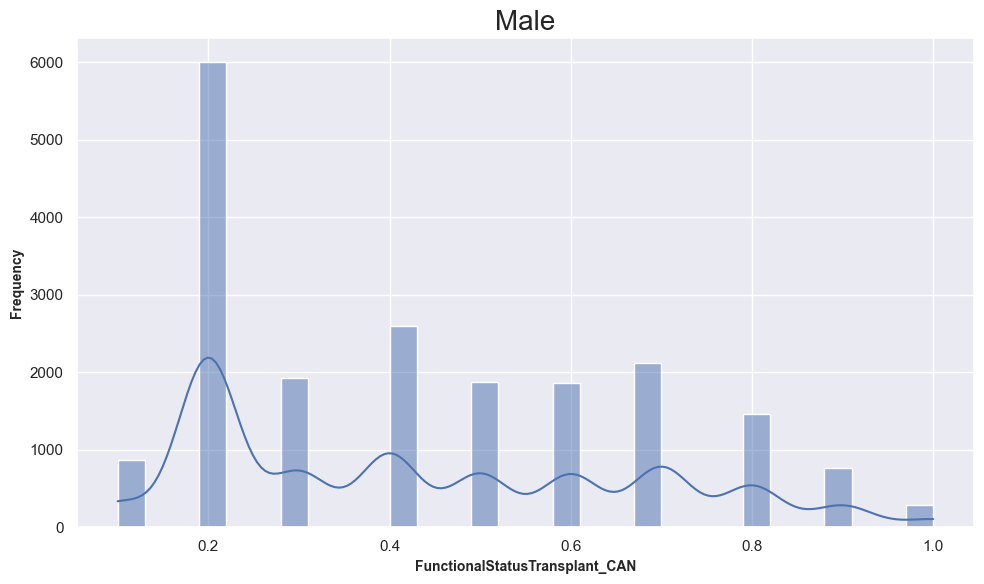

In [93]:
plot_histogram(df_m, 'FunctionalStatusTransplant_CAN', bins=30, txt='Male')

In [92]:
u.check_informative_missingness(df_m, 'FunctionalStatusTransplant_CAN', txt='Male')

--- Missingness (Male): FunctionalStatusTransplant_CAN ---
Group Sizes:    (Unknown=964, Known=19,773)
Mean survival:  (Unknown=1,095.9d, Known=1,340.9d)
Difference:     -245.0 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0000
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.2309 (Small)
95% CI:        [-0.2956, -0.1662]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



In [95]:
u.continuous_value_predicts_survival(df_m, 'FunctionalStatusTransplant_CAN', txt='Male')

--- Value Predicts Survival (Male): FunctionalStatusTransplant_CAN ---
Pearson r=0.189, p=1.166e-158 & Approx. Variance Explained=3.578%
Spearman r=0.189, p=8.058e-159 & Approx. Variance Explained=3.581%



In [94]:
u.any_nans(df_m)

--- Missing Values Found () (Total Rows: 20,737) ---
                                Count Percentage
FunctionalStatusTransplant_CAN    964    4.6487%
CreatinineRegistration_CAN         77    0.3713%
TotalBilirubinTransplant_CAN       65    0.3134%
CreatinineTransplant_CAN           41    0.1977%
WeightKg_CAN                        2    0.0096%


In [82]:
u.any_nans(df_m)

--- Missing Values Found () (Total Rows: 20,737) ---
                                  Count Percentage
FunctionalStatusTransplant_CAN      964    4.6487%
FunctionalStatusRegistration_CAN    690    3.3274%
CreatinineRegistration_CAN           77    0.3713%
TotalBilirubinTransplant_CAN         65    0.3134%
CreatinineTransplant_CAN             41    0.1977%
WeightKg_CAN                          2    0.0096%


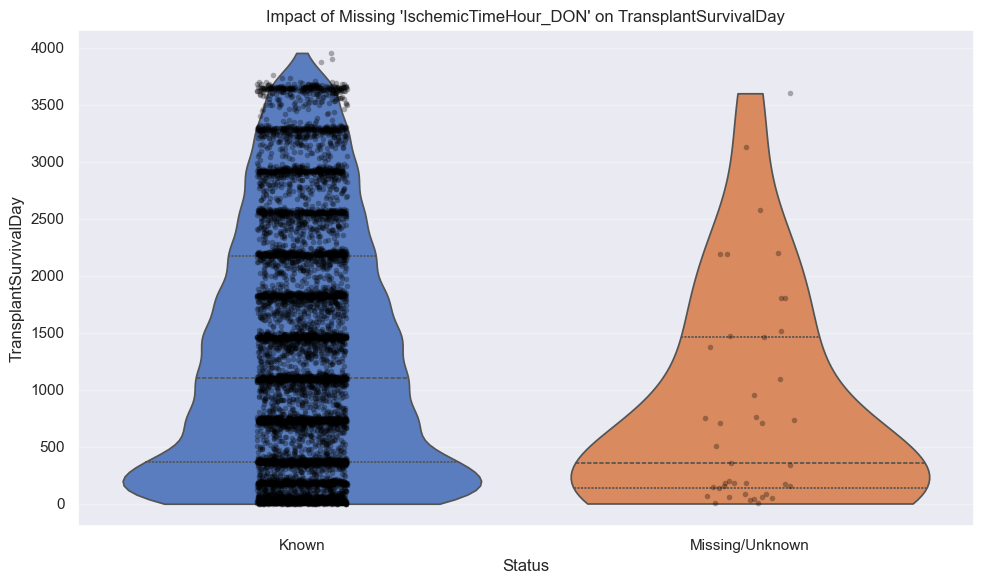

In [28]:
# plot
plot.plot_informative_missingness(df_f, 'IschemicTimeHour_DON')

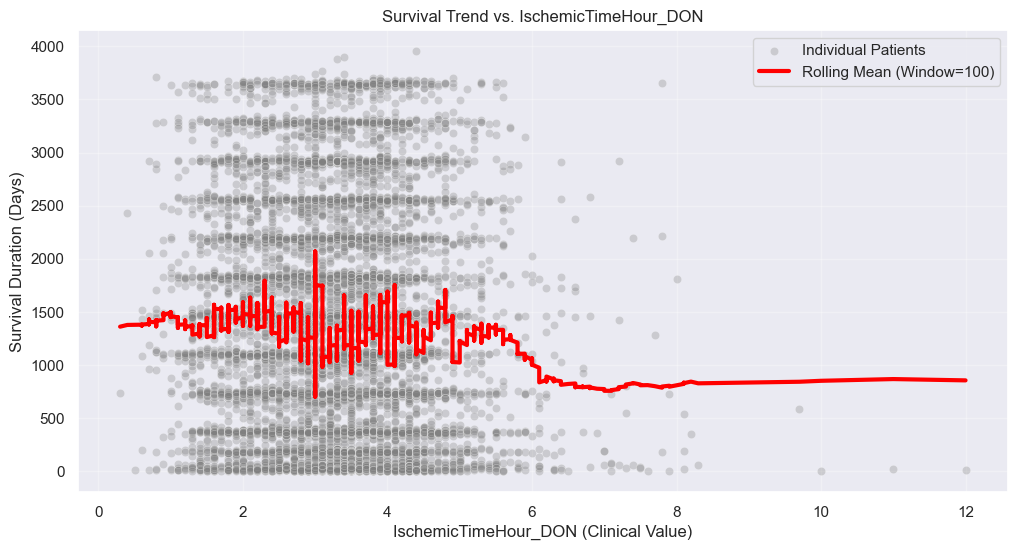

In [29]:
plot.plot_survival_trend(df_f, 'IschemicTimeHour_DON', 'TransplantSurvivalDay', window_size=100)

In [30]:
# Create the binary flag
df_m['IschemicTime_IsMissing'] = df_m['IschemicTimeHour_DON'].isna().astype(int)
df_f['IschemicTime_IsMissing'] = df_f['IschemicTimeHour_DON'].isna().astype(int)

# Fill the original NaN with the median
df_m['IschemicTimeHour_DON'] = df_m['IschemicTimeHour_DON'].fillna(df_m['IschemicTimeHour_DON'].median())
df_f['IschemicTimeHour_DON'] = df_f['IschemicTimeHour_DON'].fillna(df_f['IschemicTimeHour_DON'].median())

In [31]:
# sanity check
df_m.IschemicTime_IsMissing.sum(), df_f.IschemicTime_IsMissing.sum()

(np.int64(147), np.int64(41))

#### Write to Disk: Donor Data

In [119]:
# save data: heart dataset
u.write_to_file(df_f, 'Candidate_Female_Heart_Meds',path='../Data/', format='pkl')
u.write_to_file(df_m, 'Candidate_Male_Heart_Meds',path='../Data/', format='pkl')

8,319 records written to ../Data/Donor_Female_Heart_Meds.pkl
20,007 records written to ../Data/Donor_Male_Heart_Meds.pkl


In [ ]:
from scipy.stats import mannwhitneyu, kendalltau

def ordinal_informative_missingness(data, status_col, target_col, verbose=True):
    # --- FEATURE PREPARATION ---
    # Strip '%' and convert to 0.0-1.0 scale
    numeric_col = pd.to_numeric(
        data[status_col].astype(str).str.replace("%", "", regex=False), errors='coerce'
    ) / 100
    data[f"{status_col}_numeric"] = numeric_col

    # --- GROUP SEGMENTATION ---
    known = data.loc[data[status_col].notna(), target_col].dropna()
    unknown = data.loc[data[status_col].isna(), target_col].dropna()
    n1, n2 = len(known), len(unknown)

    if n1 < 2 or n2 < 2:
        if verbose: print(f"\n[SKIPPED] {status_col}: Not enough data.\n")
        return data

    # --- STATISTICAL CALCULATIONS ---
    mwu_stat, mwu_p = mannwhitneyu(known, unknown, alternative="two-sided")
    r_rb = 1 - (2 * mwu_stat) / (n1 * n2) # Effect size for MWU

    valid_idx = data[f"{status_col}_numeric"].notna() & data[target_col].notna()
    if valid_idx.sum() > 2:
        tau, tau_p = kendalltau(data.loc[valid_idx, f"{status_col}_numeric"], data.loc[valid_idx, target_col])
    else:
        tau, tau_p = np.nan, np.nan

    # --- FORMATTING UTILITIES ---
    def interpret_effect(r):
        if pd.isna(r): return "N/A"
        r_abs = abs(r)
        if r_abs < 0.1: return "Negligible"
        elif r_abs < 0.3: return "Small"
        elif r_abs < 0.5: return "Moderate"
        else: return "Large"

    def get_sig_label(p):
        if pd.isna(p): return "N/A"
        if p < 0.001: return "Significant (p < .001) ***"
        if p < 0.01:  return "Significant (p < .01)  **"
        if p < 0.05:  return "Significant (p < .05)  *"
        return "Not Significant"

    # --- VERBOSE REPORTING ---
    if verbose:
        print("\n" + "="*75)
        print(f" STATISTICAL REPORT: {status_col}")
        print("="*75)
        print(f"Group Sizes | Known: {n1:,} | Missing: {n2:,}")
        print("-" * 75)
        print(f"{'Metric':<25} | {'Value':<12} | {'Interpretation'}")
        print("-" * 75)

        # MWU Section (Missingness)
        print(f"{'MWU p-value':<25} | {mwu_p:<12.2e} | {get_sig_label(mwu_p)}")
        print(f"{'Rank-biserial (r)':<25} | {r_rb:<12.4f} | {interpret_effect(r_rb)} Effect")
        print("-" * 75)

        # Kendall Section (Ordinal Trend)
        print(f"{'Kendall’s Tau':<25} | {tau:<12.4f} | {interpret_effect(tau)} Association")
        print(f"{'Tau p-value':<25} | {tau_p:<12.2e} | {get_sig_label(tau_p)}")
        print("="*75)
        
        print("Conclusion:")
        # Corrected Logic: Missingness Check
        missing_impact = "is INFORMATIVE" if mwu_p < 0.05 else "is likely RANDOM"
        print(f" - Data missingness {missing_impact} (r = {r_rb:.4f})")
        
        # Corrected Logic: Ordinal Trend Check
        trend_impact = interpret_effect(tau).lower()
        sig_impact = "SIGNIFICANT" if tau_p < 0.05 else "not significant"
        print(f" - The {trend_impact} ordinal relationship is {sig_impact} for {target_col}")
        print("")

    return data